# Supplementary figures — copied from `../UPF3A_confounder.ipynb`

**This is a near-verbatim copy of the source notebook**, not a cleaned
reproduction. Only inert cells were removed: empty cells, cells that are
entirely commented out, and cells that only `print()` or display a table.
Every cell that computes or plots anything is untouched.

Panels produced here: `sup_fig6`, `sup_fig6A`–`sup_fig6F`, `sup_fig6_pr`

Two mechanical path edits were applied so the notebook runs from this directory
and cannot overwrite the published figures:

* `../code/...` → `../../code/...` (this notebook sits one level deeper)
* `../code/plots/` → `plots/` and `../code/revision_plots/` → `revision_plots/`

Cells unrelated to the supplementary panels were **kept**, so this notebook may
compute more than it needs to. That is the trade for not re-tracing it.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import gzip
from tqdm import tqdm
import os
import re

import statsmodels.api as sm


In [2]:
ds_dge = pd.read_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_pairwise_comparisons.tab.gz',
                     sep='\t', index_col=0)

In [3]:
ds_dge2 = pd.read_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/pairwise_comparisons.tab.gz',
                     sep='\t', index_col=0)

In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import rpy2.robjects as ro
import os
from rpy2.robjects import pandas2ri
import gzip
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
#from tqdm import tqdm

pairwise_comparisons = os.listdir('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/')

import numpy as np
from scipy.stats import rankdata


def process_comparison(rds_file):
    a_v_b = rds_file.split('.rds')[0]
    readRDS = ro.r['readRDS']
    rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge_confounder/rds_files/{rds_file}')
    
    ds = rds[0]
    with (ro.default_converter + pandas2ri.converter).context():
        pd_from_r_df = ro.conversion.get_conversion().rpy2py(ds)
        output = pd_from_r_df
        
    intron_list = []
    cluster_list = []
    median_count_list = []
        
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds/GTEx/{a_v_b}/ds_perind_numers.counts.noise_by_intron.lf1.gz'
    ) as fh:
        fh.readline()
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-1])
            median_counts = int(np.median([int(y) for y in line[1:]]))
            median_count_list.append(median_counts)
    
    intron_median_counts = pd.DataFrame()
    intron_median_counts['intron'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts['median_counts'] = median_count_list
    
    ds = pd.merge(output, intron_median_counts, right_on=['intron', 'cluster'], left_on=['intron', 'cluster'])
    
    return ds

def process_comparison_uncorrected(rds_file):
    a_v_b = rds_file.split('.rds')[0]
    readRDS = ro.r['readRDS']
    rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds_v_dge/{rds_file}')
    
    ds = rds[0]
    with (ro.default_converter + pandas2ri.converter).context():
        pd_from_r_df = ro.conversion.get_conversion().rpy2py(ds)
        output = pd_from_r_df
        
    intron_list = []
    cluster_list = []
    median_count_list = []
        
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds/GTEx/{a_v_b}/ds_perind_numers.counts.noise_by_intron.lf1.gz'
    ) as fh:
        fh.readline()
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-1])
            median_counts = int(np.median([int(y) for y in line[1:]]))
            median_count_list.append(median_counts)
    
    intron_median_counts = pd.DataFrame()
    intron_median_counts['intron'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts['median_counts'] = median_count_list
    
    ds = pd.merge(output, intron_median_counts, right_on=['intron', 'cluster'], left_on=['intron', 'cluster'])
    
    return ds

During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 


In [5]:
ds = process_comparison('Brain-Cerebellum_v_Muscle-Skeletal.rds')
ds_u = process_comparison_uncorrected('Brain-Cerebellum_v_Muscle-Skeletal.rds')

In [6]:
ds_idx = ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].index
ds_u_idx = ds.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].index

shared_idx = ds_idx.intersection(ds_u_idx)


In [7]:
spearmanr(np.array(ds.loc[shared_idx].deltapsi),
    np.array(ds_u.loc[shared_idx].deltapsi))

SignificanceResult(statistic=np.float64(0.7865302462252196), pvalue=np.float64(7.551397999194944e-71))

Text(0, 0.5, '$\\Delta$ PSI (corrected)')

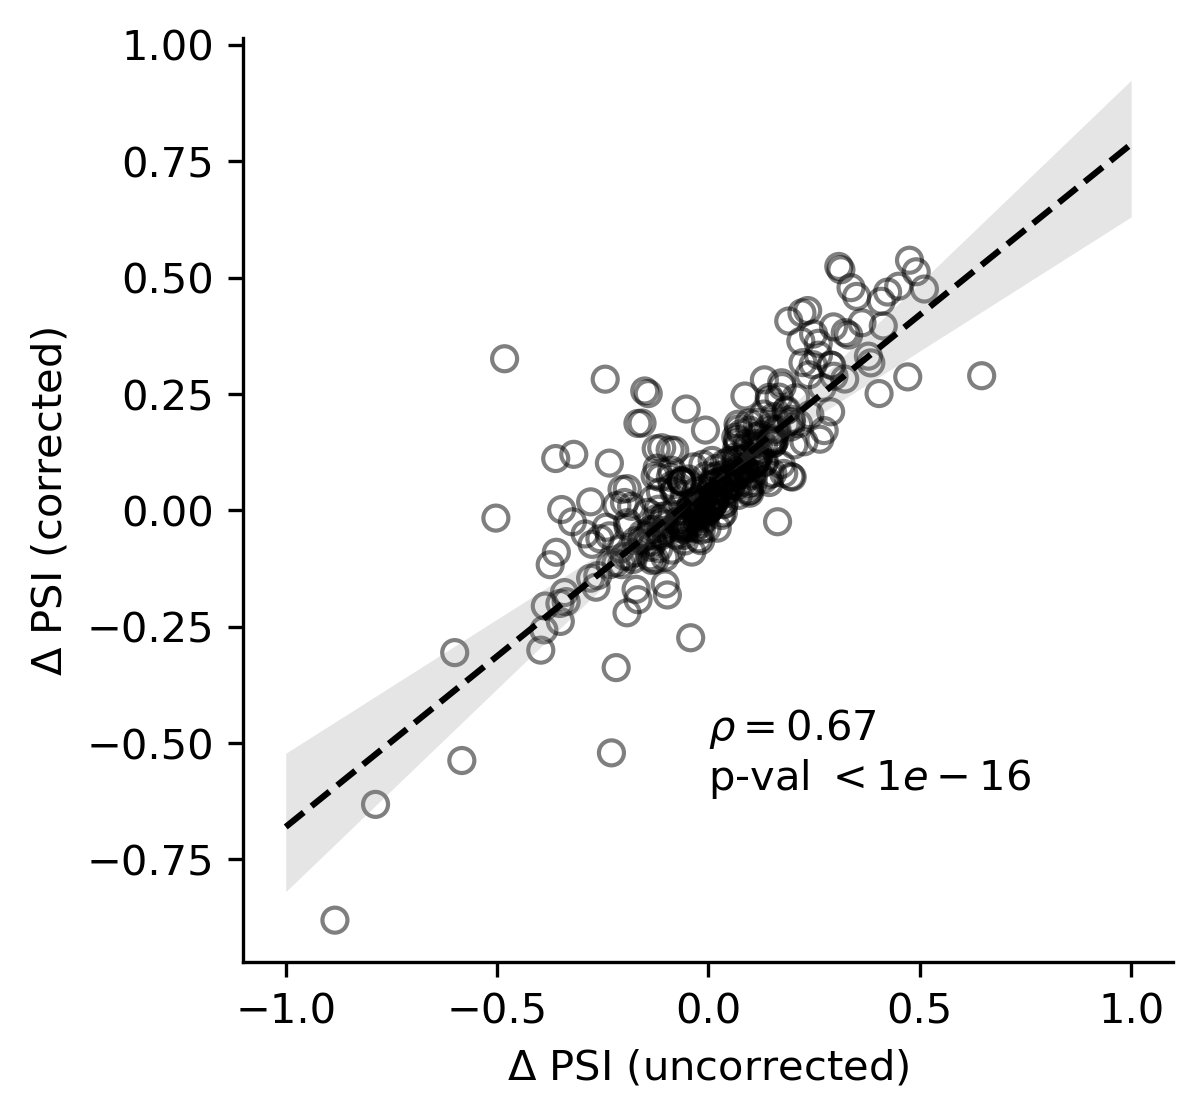

In [8]:

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
ax.scatter(np.array(ds.loc[shared_idx].deltapsi),
    np.array(ds_u.loc[shared_idx].deltapsi), facecolor='none', edgecolor='black', alpha=0.5
)




Y = ds_u.loc[shared_idx].deltapsi
X = ds.loc[shared_idx].deltapsi
X = sm.add_constant(X)


rho_list = []
for i in range(100):
    idx = np.random.choice(np.arange(len(X)), 50, replace=False)
    
    Y_ = Y.iloc[idx]
    X_ = X.iloc[idx]
    X_ = sm.add_constant(X_)

    
    model = sm.RLM(Y_,X_)
    results = model.fit()

    slope = results.params.iloc[1]
    const = results.params.iloc[0]

    rho_list.append(slope)

# slope = pearsonr(list(ds_sig.logef), list(ds_sig.log2FoldChange))[0]
# intercept = np.mean(list(ds_sig.log2FoldChange))
slope_90 = np.quantile(rho_list, 0.9)
slope_10 = np.quantile(rho_list, 0.1)

# Plot confidence intervals (optional)

model = sm.RLM(Y,X)
results = model.fit()

slope = results.params.loc['deltapsi']
const = results.params.loc['const']

mean_X = np.mean(X.deltapsi)

x = np.linspace(-1-mean_X, 1-mean_X, 100) 

ax.plot(x + mean_X, (slope * (x+mean_X)) + const, color='black', linestyle='--')


ax.fill_between(x + mean_X,( slope_90 * np.array(x)) + const + (slope*mean_X), 
                (slope_10 * x) + const+ (slope*mean_X), 
                 color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.text(0.0, -0.6, r'$\rho=0.67$' + '\np-val ' + r'$< 1e-16$')

ax.spines[['top', 'right']].set_visible(False)

ax.set_xlabel(r'$\Delta$ PSI (uncorrected)')
ax.set_ylabel(r'$\Delta$ PSI (corrected)')

In [9]:
ds_idx = ds.loc[(ds.itype=='PR') & (ds.ctype=='PR') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].index
ds_u_idx = ds.loc[(ds_u.itype=='PR') & (ds_u.ctype=='PR') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].index

shared_idx = ds_idx.intersection(ds_u_idx)


In [10]:
spearmanr(np.array(ds.loc[shared_idx].deltapsi),
    np.array(ds_u.loc[shared_idx].deltapsi))

SignificanceResult(statistic=np.float64(0.8690404694510699), pvalue=np.float64(0.0))

Text(0, 0.5, '$\\Delta$ PSI (corrected)')

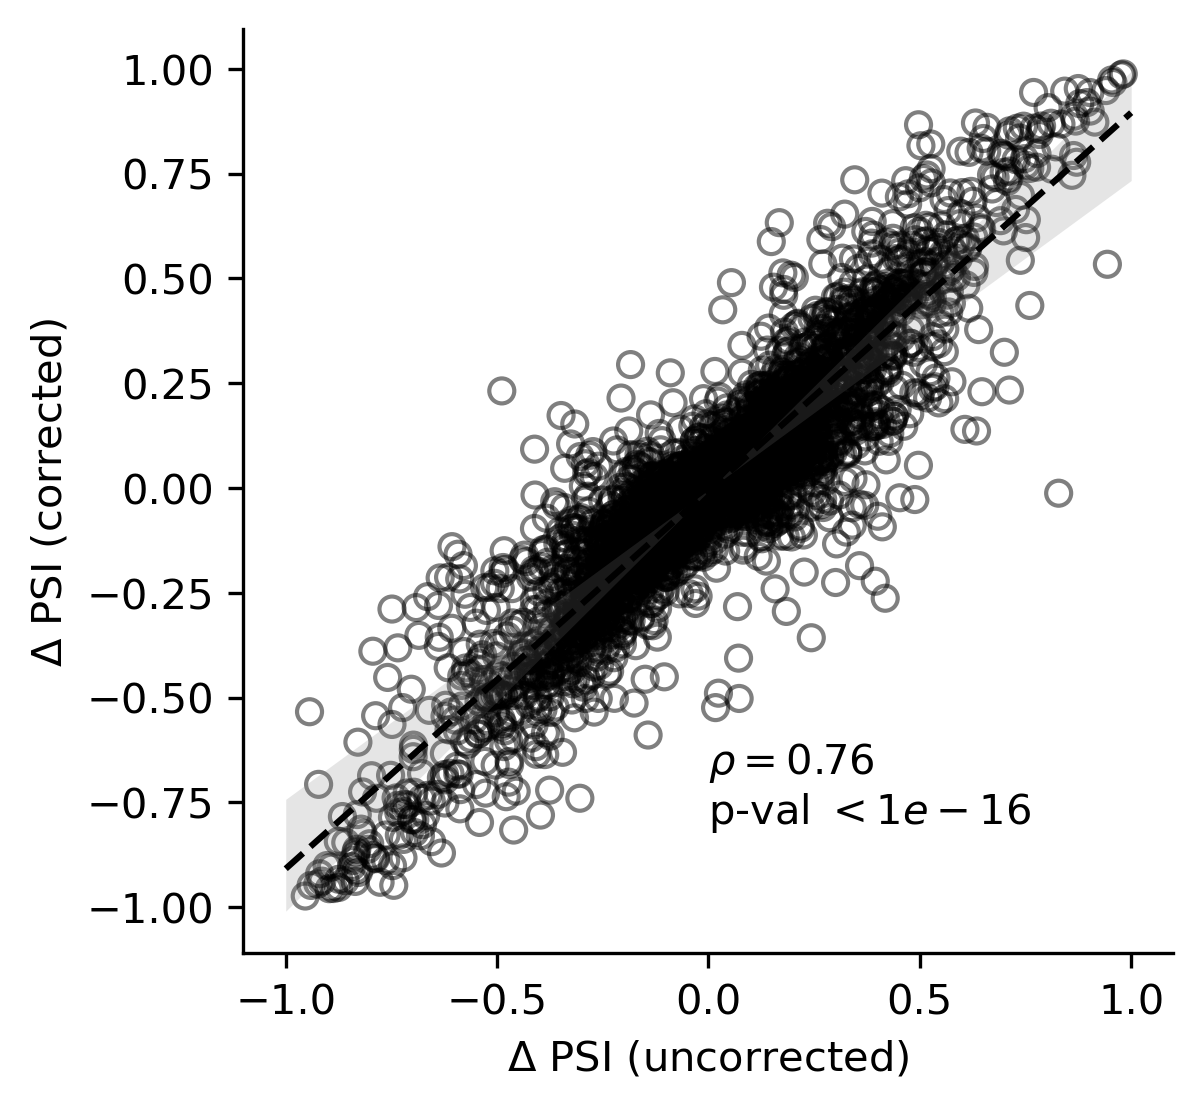

In [11]:

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
ax.scatter(np.array(ds.loc[shared_idx].deltapsi),
    np.array(ds_u.loc[shared_idx].deltapsi), facecolor='none', edgecolor='black', alpha=0.5
)




Y = ds_u.loc[shared_idx].deltapsi
X = ds.loc[shared_idx].deltapsi
X = sm.add_constant(X)


rho_list = []
for i in range(100):
    idx = np.random.choice(np.arange(len(X)), 50, replace=False)
    
    Y_ = Y.iloc[idx]
    X_ = X.iloc[idx]
    X_ = sm.add_constant(X_)

    
    model = sm.RLM(Y_,X_)
    results = model.fit()

    slope = results.params.iloc[1]
    const = results.params.iloc[0]

    rho_list.append(slope)

# slope = pearsonr(list(ds_sig.logef), list(ds_sig.log2FoldChange))[0]
# intercept = np.mean(list(ds_sig.log2FoldChange))
slope_90 = np.quantile(rho_list, 0.9)
slope_10 = np.quantile(rho_list, 0.1)

# Plot confidence intervals (optional)

model = sm.RLM(Y,X)
results = model.fit()

slope = results.params.loc['deltapsi']
const = results.params.loc['const']

mean_X = np.mean(X.deltapsi)

x = np.linspace(-1-mean_X, 1-mean_X, 100) 

ax.plot(x + mean_X, (slope * (x+mean_X)) + const, color='black', linestyle='--')


ax.fill_between(x + mean_X,( slope_90 * np.array(x)) + const + (slope*mean_X), 
                (slope_10 * x) + const+ (slope*mean_X), 
                 color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.text(0.0, -0.8, r'$\rho=0.76$' + '\np-val ' + r'$< 1e-16$')

ax.spines[['top', 'right']].set_visible(False)

ax.set_xlabel(r'$\Delta$ PSI (uncorrected)')
ax.set_ylabel(r'$\Delta$ PSI (corrected)')

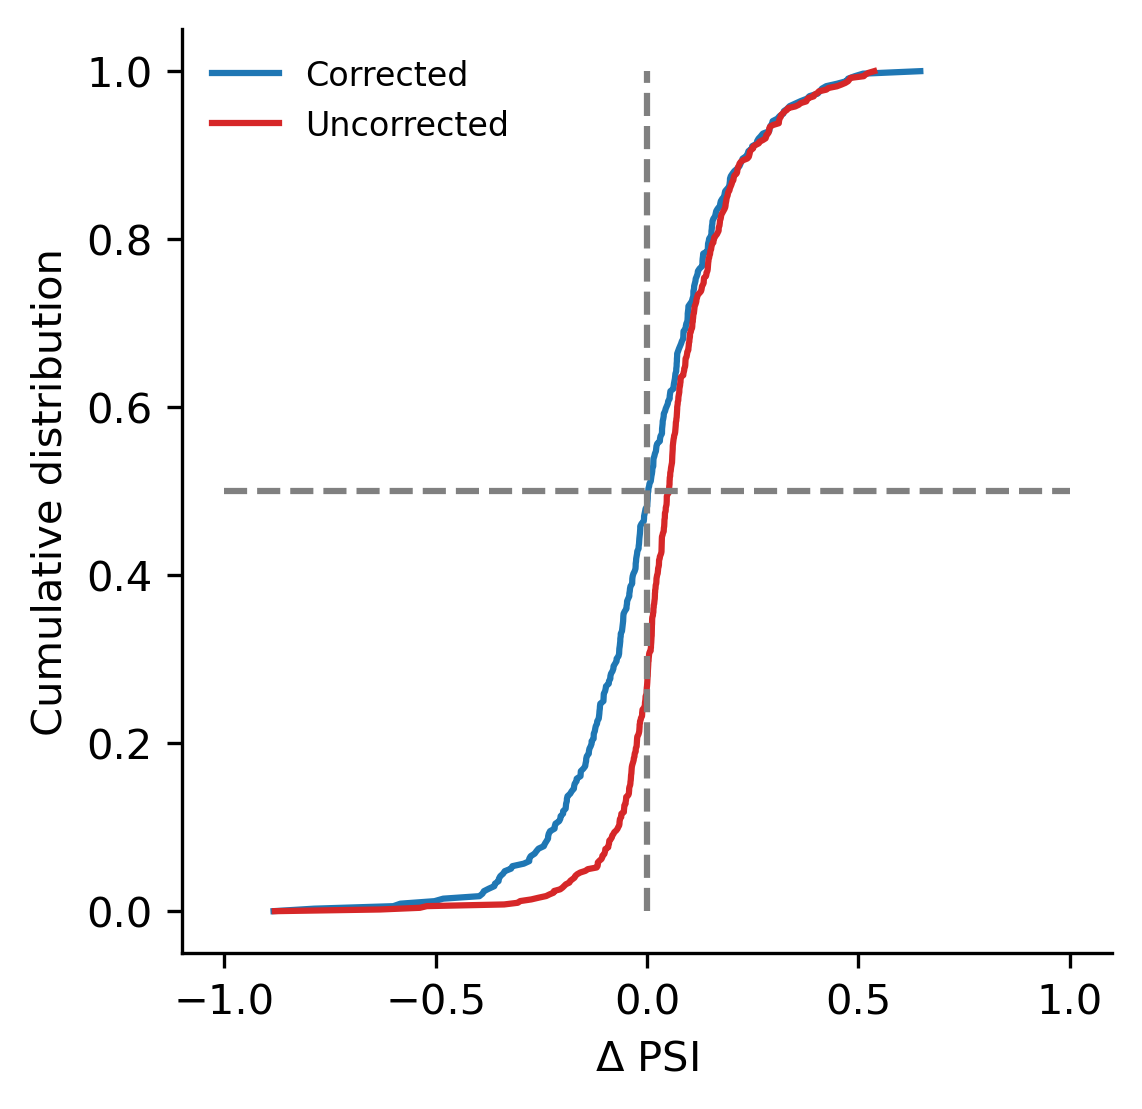

In [12]:
fig, ax = plt.subplots(figsize=(4,4), dpi=300)
y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Corrected'
    )

y_dkd = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'Uncorrected', c='tab:red'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

In [4]:
dPSI_median = pd.read_csv('../../code/results/ds_v_dge_confounder/deltaPSI_median.tsv.gz', sep='\t', index_col=0)
dPSI_median_pr = pd.read_csv('../../code/results/ds_v_dge_confounder/deltaPSI_median_protein-coding.tsv.gz', sep='\t', index_col=0)
inflection_points = pd.read_csv('../../code/results/ds_v_dge_confounder/inflection_points.tsv.gz', sep='\t', index_col=0)

In [12]:
select_tissues = [x for x in inflection_points.index if ('Testis' in x) or ('Cerebell' in x) or ('Culturedfibro' in x) or ('Muscl' in x) or ('LeftVentri' in x)]

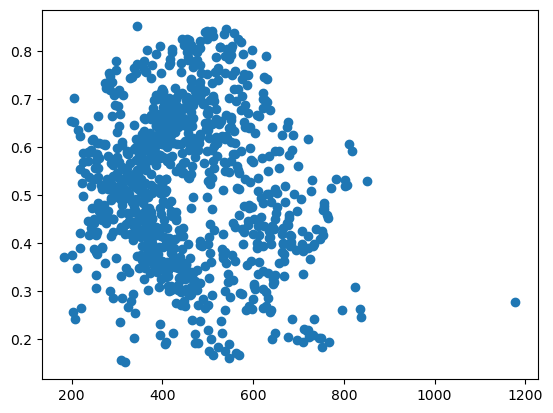

In [181]:
plt.scatter(inflection_points.uncorrected_n, inflection_points.uncorrected_inf)

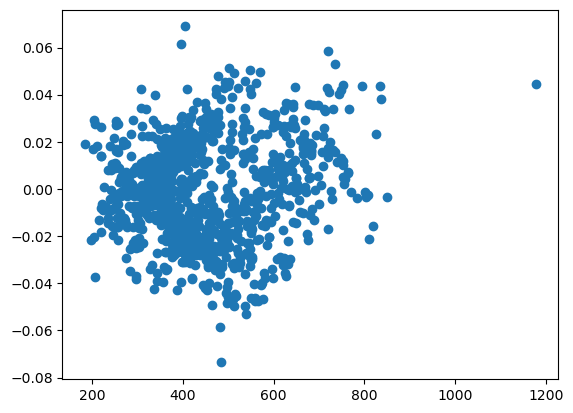

In [182]:
plt.scatter(dPSI_median.uncorrected_n, dPSI_median.uncorrected_med)

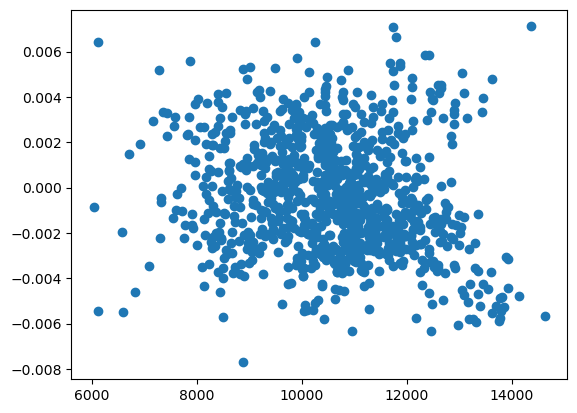

In [5]:
plt.scatter(dPSI_median_pr.uncorrected_n, dPSI_median_pr.uncorrected_med)

In [7]:
y = np.linspace(0, 1, inflection_points.shape[0])

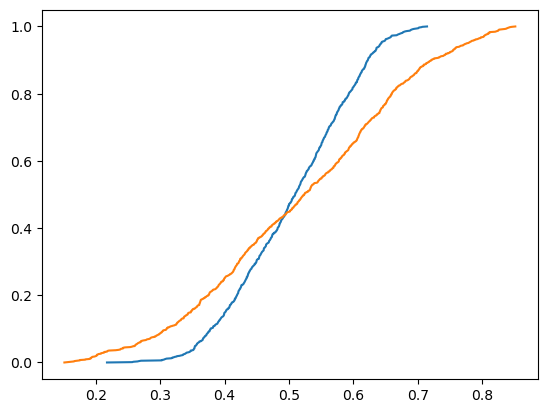

In [8]:
plt.plot(sorted(inflection_points.corrected_inf), y)
plt.plot(sorted(inflection_points.uncorrected_inf), y)

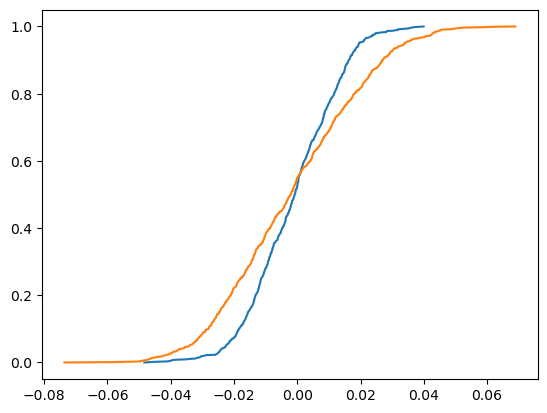

In [9]:
plt.plot(sorted(dPSI_median.corrected_med), y)
plt.plot(sorted(dPSI_median.uncorrected_med), y)

NameError: name 'select_tissues' is not defined

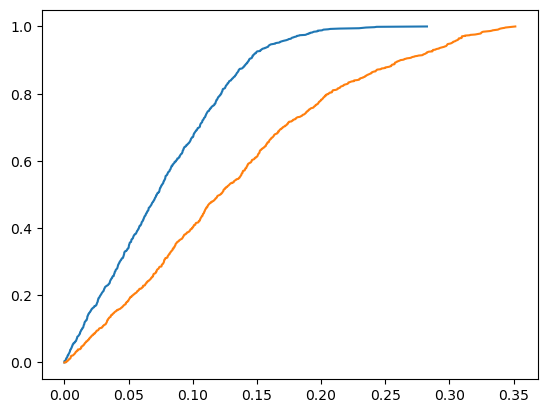

In [10]:
plt.plot(sorted((inflection_points.corrected_inf - 0.5).abs()), y)
plt.plot(sorted((inflection_points.uncorrected_inf - 0.5).abs()), y)

y_ = np.linspace(0, 1, len(select_tissues))
# plt.plot(sorted((inflection_points.loc[select_tissues].corrected_inf - 0.5).abs()), y_)
plt.plot(sorted((inflection_points.loc[select_tissues].uncorrected_inf - 0.5).abs()), y_)

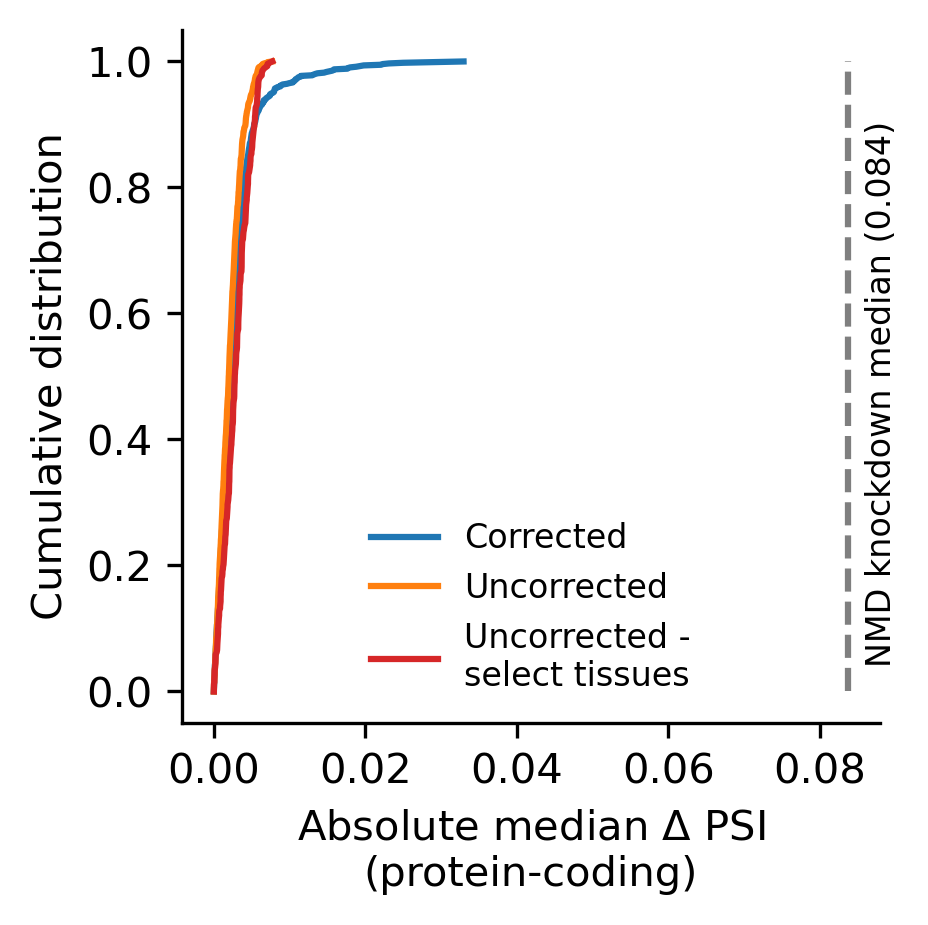

In [17]:
fig, ax = plt.subplots(figsize=(3,3), dpi=300)
ax.plot(sorted((dPSI_median_pr.corrected_med).abs()), y, label='Corrected')
ax.plot(sorted((dPSI_median_pr.uncorrected_med).abs()), y, label='Uncorrected')

y_ = np.linspace(0, 1, len(select_tissues))
# plt.plot(sorted((inflection_points.loc[select_tissues].corrected_inf - 0.5).abs()), y_)
ax.plot(sorted((dPSI_median_pr.loc[select_tissues].uncorrected_med).abs()), y_, label='Uncorrected -\nselect tissues',
       c='tab:red')

# ax.plot([np.median(y_dkd), np.median(y_dkd)], [0, 1], c='tab:gray')
ax.legend(frameon=False, fontsize=8)
ax.set_xlabel(r'Absolute median $\Delta$ PSI'+'\n(protein-coding)')
ax.set_ylabel('Cumulative distribution')

ax.plot([np.median(0.0837), np.median(0.0837)], [0, 1], c='tab:gray', linestyle='--')

ax.text(0.086, 0.05, 'NMD knockdown median (0.084)', rotation=90, size=8)

ax.spines[['top', 'right']].set_visible(False)


plt.savefig('plots/sup_fig6_pr.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6_pr.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6_pr.svg', dpi=300, bbox_inches='tight') 

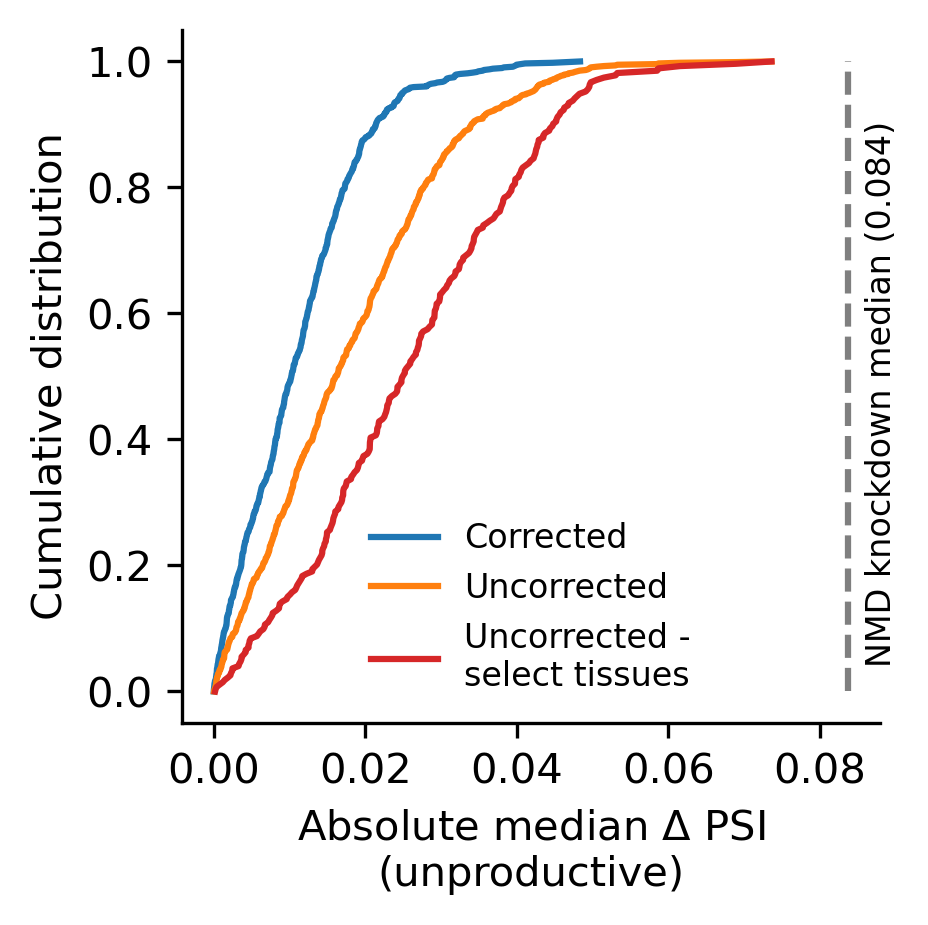

In [20]:
fig, ax = plt.subplots(figsize=(3,3), dpi=300)
ax.plot(sorted((dPSI_median.corrected_med).abs()), y, label='Corrected')
ax.plot(sorted((dPSI_median.uncorrected_med).abs()), y, label='Uncorrected')

y_ = np.linspace(0, 1, len(select_tissues))
# plt.plot(sorted((inflection_points.loc[select_tissues].corrected_inf - 0.5).abs()), y_)
ax.plot(sorted((dPSI_median.loc[select_tissues].uncorrected_med).abs()), y_, label='Uncorrected -\nselect tissues',
       c='tab:red')

# ax.plot([np.median(y_dkd), np.median(y_dkd)], [0, 1], c='tab:gray')
ax.legend(frameon=False, fontsize=8)
ax.set_xlabel(r'Absolute median $\Delta$ PSI' + '\n(unproductive)')
ax.set_ylabel('Cumulative distribution')

ax.plot([np.median(0.0837), np.median(0.0837)], [0, 1], c='tab:gray', linestyle='--')

ax.text(0.086, 0.05, 'NMD knockdown median (0.084)', rotation=90, size=8)

ax.spines[['top', 'right']].set_visible(False)


plt.savefig('plots/sup_fig6.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6.svg', dpi=300, bbox_inches='tight') 

In [204]:
np.median(y_dkd)

np.float64(0.0837790430927752)

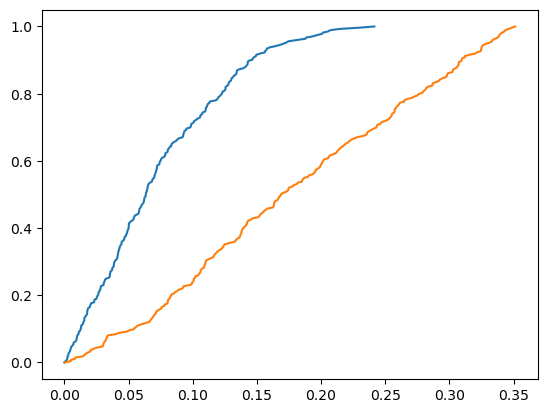

In [87]:
y_ = np.linspace(0, 1, len(select_tissues))
plt.plot(sorted((inflection_points.loc[select_tissues].corrected_inf - 0.5).abs()), y_)
plt.plot(sorted((inflection_points.loc[select_tissues].uncorrected_inf - 0.5).abs()), y_)

In [74]:
(inflection_points.corrected_inf - 0.5).abs().median()

np.float64(0.07205298518857844)

In [75]:
(inflection_points.loc[select_tissues].corrected_inf - 0.5).abs().median()

np.float64(0.0634390496632374)

In [76]:
(inflection_points.uncorrected_inf - 0.5).abs().median()

np.float64(0.1215250965250965)

In [77]:
(inflection_points.loc[select_tissues].uncorrected_inf - 0.5).abs().median()

np.float64(0.16884181392378117)

In [ ]:
ds = process_comparison('Brain-Cerebellum_v_Muscle-Skeletal.rds')
ds_u = process_comparison_uncorrected('Brain-Cerebellum_v_Muscle-Skeletal.rds')

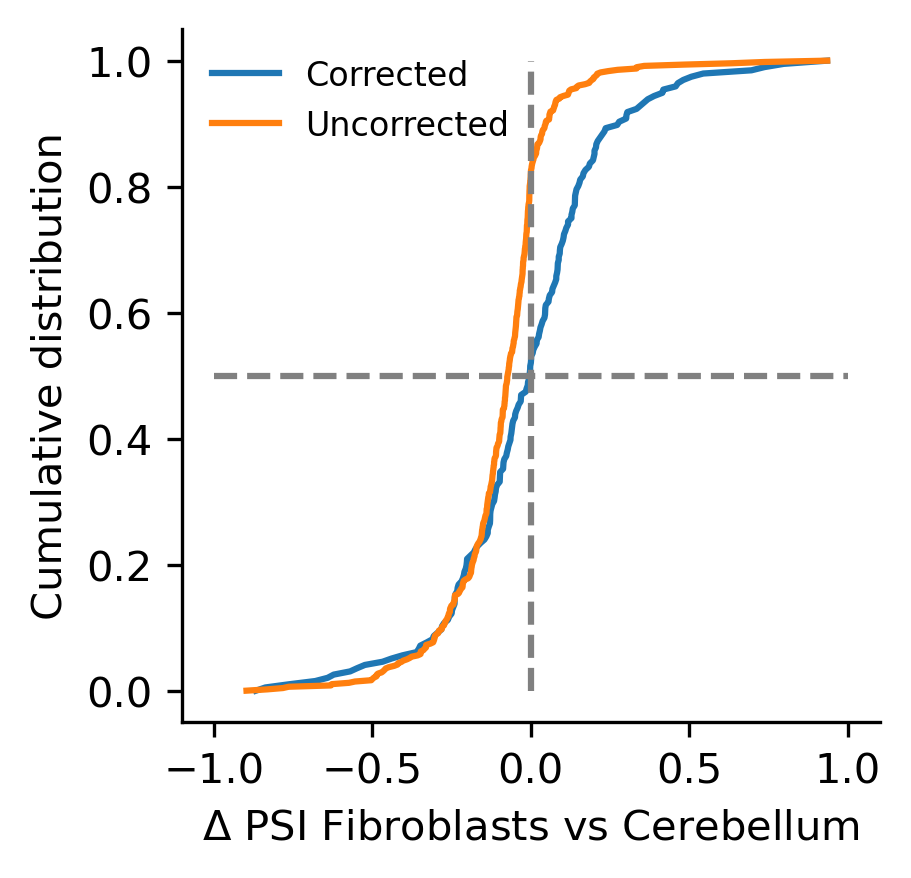

In [170]:
ds = process_comparison('Cells-Culturedfibroblasts_v_Brain-Cerebellum.rds')
ds_u = process_comparison_uncorrected('Cells-Culturedfibroblasts_v_Brain-Cerebellum.rds')

fig, ax = plt.subplots(figsize=(3,3), dpi=300)
y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Corrected'
    )

y_dkd = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'Uncorrected', c='tab:orange'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI Fibroblasts vs Cerebellum')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

plt.savefig('plots/sup_fig6A.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6A.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6A.svg', dpi=300, bbox_inches='tight') 

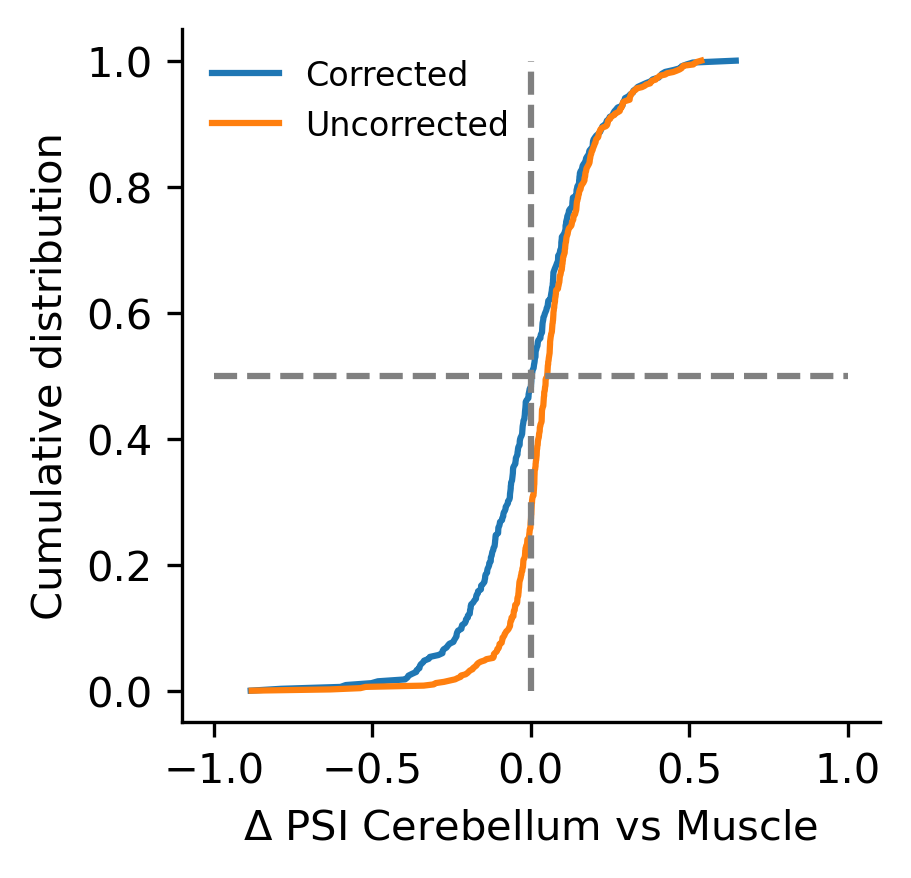

In [174]:
ds = process_comparison('Brain-Cerebellum_v_Muscle-Skeletal.rds')
ds_u = process_comparison_uncorrected('Brain-Cerebellum_v_Muscle-Skeletal.rds')

fig, ax = plt.subplots(figsize=(3,3), dpi=300)
y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Corrected'
    )

y_dkd = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'Uncorrected', c='tab:orange'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI Cerebellum vs Muscle')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

plt.savefig('plots/sup_fig6B.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6B.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6B.svg', dpi=300, bbox_inches='tight') 

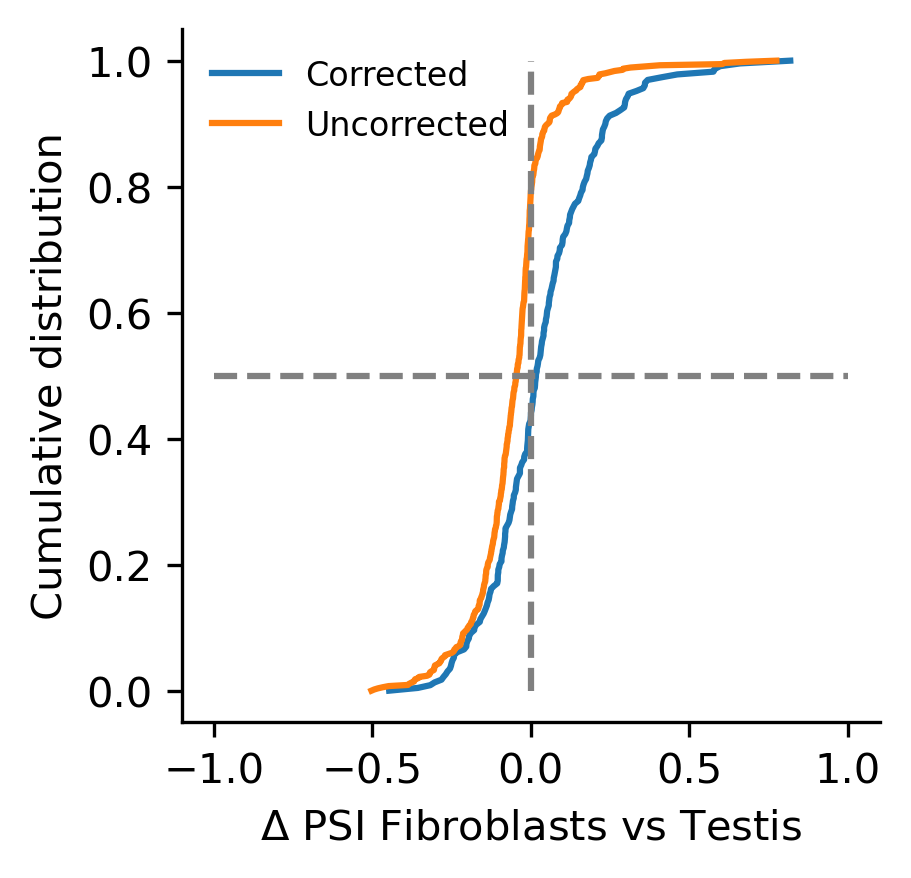

In [172]:
ds = process_comparison('Cells-Culturedfibroblasts_v_Testis.rds')
ds_u = process_comparison_uncorrected('Cells-Culturedfibroblasts_v_Testis.rds')

fig, ax = plt.subplots(figsize=(3,3), dpi=300)
y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Corrected'
    )

y_dkd = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'Uncorrected', c='tab:orange'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI Fibroblasts vs Testis')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

plt.savefig('plots/sup_fig6C.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6C.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6C.svg', dpi=300, bbox_inches='tight') 

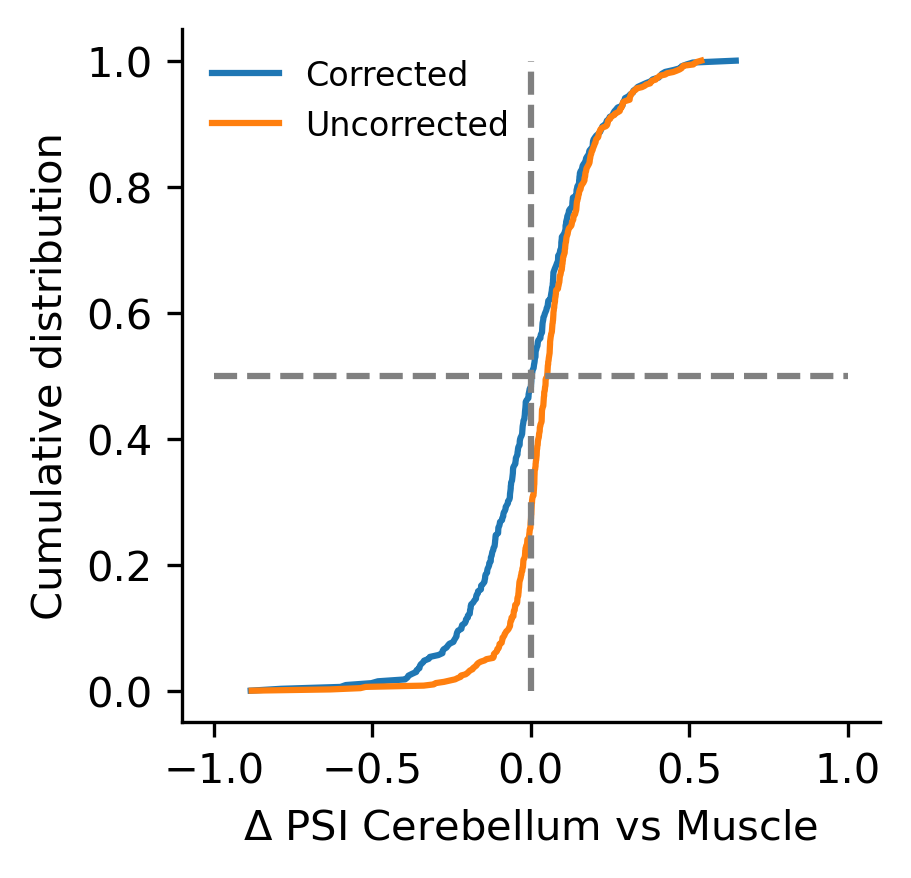

In [175]:
ds = process_comparison('Brain-Cerebellum_v_Muscle-Skeletal.rds')
ds_u = process_comparison_uncorrected('Brain-Cerebellum_v_Muscle-Skeletal.rds')

fig, ax = plt.subplots(figsize=(3,3), dpi=300)
y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Corrected'
    )

y_dkd = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'Uncorrected', c='tab:orange'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI Cerebellum vs Muscle')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

plt.savefig('plots/sup_fig6D.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6D.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6D.svg', dpi=300, bbox_inches='tight') 

In [49]:
def find_inflection(y):
    yln = np.linspace(0, 1, len(y))
    y_neg = np.array(sorted(y)) < 0
    yn = y_neg.sum()
    inflection = yln[yn]
    return inflection

def get_inflection_pairwise(pairwise):
    ds = process_comparison(f'{pairwise}.rds')
    ds_u = process_comparison_uncorrected(f'{pairwise}.rds')
    y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)
    y_u = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
    inf_y = find_inflection(y)
    inf_yu = find_inflection(y_u)
    return (pairwise, len(y), inf_y, len(y_u), inf_yu)


def get_median_pairwise(pairwise):
    ds = process_comparison(f'{pairwise}.rds')
    ds_u = process_comparison_uncorrected(f'{pairwise}.rds')
    y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)
    y_u = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
    inf_y = np.median(y)
    inf_yu = np.median(y_u)
    return (pairwise, len(y), inf_y, len(y_u), inf_yu)


median_points = []
for pairwise in tqdm(ds_dge2.loc[ds_dge2.n >= 30].index):
    try:
        m_points = get_median_pairwise(pairwise)
        median_points.append(m_points)
    except:
        continue

In [ ]:
def get_median_pairwise_pr(pairwise):
    ds = process_comparison(f'{pairwise}.rds')
    ds_u = process_comparison_uncorrected(f'{pairwise}.rds')
    y = np.array(ds.loc[(ds.itype=='PR') & (ds.ctype=='PR') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)
    y_u = np.array(ds_u.loc[(ds_u.itype=='PR') & (ds_u.ctype=='PR') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
    inf_y = np.median(y)
    inf_yu = np.median(y_u)
    return (pairwise, len(y), inf_y, len(y_u), inf_yu)


median_points_pr = []
for pairwise in tqdm(ds_dge2.loc[ds_dge2.n >= 30].index):
    try:
        m_points = get_median_pairwise_pr(pairwise)
        median_points_pr.append(m_points)
    except:
        continue

In [ ]:
inflection_points = []
for pairwise in tqdm(ds_dge2.loc[ds_dge2.n >= 30].index):
    try:
        inf_points = get_inflection_pairwise(pairwise)
        inflection_points.append(inf_points)
    except:
        continue

  4%|██████▋                                                                                                                                                  | 42/960 [06:20<04:51,  3.15it/s]

In [38]:
med_df = pd.DataFrame(median_points)
med_df.columns = ['pairwise', 'corrected_n', 'corrected_med', 'uncorrected_n', 'uncorrected_med']
med_df = med_df.set_index('pairwise')

med_df.to_csv('results/ds_v_dge_confounder/deltaPSI_median.tsv.gz', sep='\t', header=True, index=True)

np.float64(0.272)

In [ ]:
med_df = pd.DataFrame(median_points_pr)
med_df.columns = ['pairwise', 'corrected_n', 'corrected_med', 'uncorrected_n', 'uncorrected_med']
med_df = med_df.set_index('pairwise')

med_df.to_csv('results/ds_v_dge_confounder/deltaPSI_median_protein-coding.tsv.gz', sep='\t', header=True, index=True)

In [ ]:
inf_df = pd.DataFrame(inflection_points)
inf_df.columns = ['pairwise', 'corrected_n', 'corrected_inf', 'uncorrected_n', 'uncorrected_inf']
inf_df = inf_df.set_index('pairwise')

inf_df.to_csv('results/ds_v_dge_confounder/inflection_points.tsv.gz', sep='\t', header=True, index=True)

In [39]:
find_inflection(y)

np.float64(0.4821428571428571)

In [40]:
np.mean(np.array(sorted(y)) > 0 )

np.float64(0.5192878338278932)

In [42]:
len(y)

337

In [43]:
len(y_dkd)

501

In [14]:
# Alignments/STAR_Align/NMD_KD/HeLa.SMG6.KD:
# SRR4081231  SRR4081232  SRR4081233

# Alignments/STAR_Align/NMD_KD/HeLa.SMG7.KD:
# SRR4081240  SRR4081241  SRR4081242

# Alignments/STAR_Align/NMD_KD/HeLa.UPF1.KD:
# SRR4081225  SRR4081226  SRR4081227

# Alignments/STAR_Align/NMD_KD/HeLa.dKD:
# SRR4081246  SRR4081247  SRR4081248

# Alignments/STAR_Align/NMD_KD/HeLa.scr:
# SRR4081222  SRR4081223  SRR4081224  SRR4081237  SRR4081238  SRR4081239

smg6 = ['SRR4081231', 'SRR4081232', 'SRR4081233']
smg7 = ['SRR4081240', 'SRR4081241', 'SRR4081242']
upf1 = ['SRR4081225', 'SRR4081226', 'SRR4081227']
dkd = ['SRR4081246', 'SRR4081247', 'SRR4081248']
control = ['SRR4081222', 'SRR4081223', 'SRR4081224', 'SRR4081237', 'SRR4081238', 'SRR4081239']

tfile = '/project2/yangili1/cfbuenabadn/ChromatinSplicingQTLs/code/Alignments/STAR_Align/NMD_KD/{condition}/{sample}/1/SJ.out.tab'
bfile = '/project2/yangili1/cfbuenabadn/ChromatinSplicingQTLs/code/Alignments/STAR_Align/NMD_KD/{condition}/{sample}/1/Filtered.bam'
baifile = '/project2/yangili1/cfbuenabadn/ChromatinSplicingQTLs/code/Alignments/STAR_Align/NMD_KD/{condition}/{sample}/1/Filtered.bam.bai'

with open('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/config/HeLa_samples.tsv', 'w') as fh:
    
    fh.write('sampleID\tcondition\tpath_to_file\tbam_file\tbai_file\n')

    for sample in smg6:
        row = [sample, 'HeLa_SMG6', tfile.format(condition='HeLa.SMG6.KD', sample=sample), 
              bfile.format(condition='HeLa.SMG6.KD', sample=sample),
              baifile.format(condition='HeLa.SMG6.KD', sample=sample)]
        line = '\t'.join(row) + '\n'
        fh.write(line)


    for sample in smg7:
        row = [sample, 'HeLa_SMG7', tfile.format(condition='HeLa.SMG7.KD', sample=sample), 
              bfile.format(condition='HeLa.SMG7.KD', sample=sample),
              baifile.format(condition='HeLa.SMG7.KD', sample=sample)]
        line = '\t'.join(row) + '\n'
        fh.write(line)

    for sample in upf1:
        row = [sample, 'HeLa_UPF1', tfile.format(condition='HeLa.UPF1.KD', sample=sample), 
              bfile.format(condition='HeLa.UPF1.KD', sample=sample),
              baifile.format(condition='HeLa.UPF1.KD', sample=sample)]
        line = '\t'.join(row) + '\n'
        fh.write(line)

    for sample in dkd:
        row = [sample, 'HeLa_dKD', tfile.format(condition='HeLa.dKD', sample=sample), 
              bfile.format(condition='HeLa.dKD', sample=sample),
              baifile.format(condition='HeLa.dKD', sample=sample)]
        line = '\t'.join(row) + '\n'
        fh.write(line)

    for sample in control:
        row = [sample, 'HeLa_controls', tfile.format(condition='HeLa.scr', sample=sample), 
              bfile.format(condition='HeLa.scr', sample=sample),
              baifile.format(condition='HeLa.scr', sample=sample)]
        line = '\t'.join(row) + '\n'
        fh.write(line)

In [15]:
gene_names = pd.read_csv('../../code/annotations/gencode.v34.gene_id_name.tab.gz', sep='\t', names=['gene_id', 'gene_name'])

In [22]:
condition = 'HeLa_dKD'
cnts_file_1 = '../../code/resources/HeLa/counts/HeLa_controls/Counts.txt'
cnts_file_2 = f'../../code/resources/HeLa/counts/{condition}/Counts.txt'
with open(cnts_file_1, 'r') as fh:
    with open(cnts_file_2, 'r') as fh2:
        fh.readline()
        fh2.readline()
        
        fh_cols = fh.readline().rstrip().split()
        fh2_cols = fh2.readline().rstrip().split()
        
        samples_1 = [x.split('/')[-3] for x in fh_cols[6:]]
        samples_2 = [x.split('/')[-3] for x in fh2_cols[6:]]
        
        for line_1 in fh:
            line_2 = fh2.readline()
            row_1 = line_1.rstrip().split('\t')
            row_2 = line_2.rstrip().split('\t')
            
            gene = row_1[0]
            
            gene_name = gene_names.loc[gene_names.gene_id == gene].gene_name
            
            cnts_1 = row_1[6:]
            cnts_2 = row_2[6:]

In [21]:
[x.split('/')[-3] for x in fh_cols[6:]]

['SRR4081222',
 'SRR4081223',
 'SRR4081224',
 'SRR4081237',
 'SRR4081238',
 'SRR4081239']

In [32]:
groups = pd.read_csv('../../code/results/ds/GTEx/Testis_v_WholeBlood/ds_sample_group.txt', sep=' ', 
                  names = ['sample', 'tissue'])

data = pd.read_csv('../../code/results/ds/GTEx/Testis_v_WholeBlood/ds_perind_numers.counts.noise_by_intron.gz', sep=' ')

datalog = pd.DataFrame(np.log(data.loc[data.chrom.apply(lambda x: x.endswith(':UP')), data.columns[1:]].sum(axis=0)))
datalog.columns = ['logUP']

groups.merge(datalog, left_on='sample', right_index=True)

In [44]:
groups.merge(datalog, left_on='sample', right_index=True)

,sample,tissue,logUP
0,WholeBlood.GTEX-111YS.tsv.gz,WholeBlood,10.771092
1,WholeBlood.GTEX-1122O.tsv.gz,WholeBlood,10.826019
2,WholeBlood.GTEX-1128S.tsv.gz,WholeBlood,10.990314
3,WholeBlood.GTEX-113IC.tsv.gz,WholeBlood,10.754728
4,WholeBlood.GTEX-113JC.tsv.gz,WholeBlood,10.684371
...,...,...,...
155,Testis.GTEX-147GR.tsv.gz,Testis,11.249324
156,Testis.GTEX-147JS.tsv.gz,Testis,11.537403
157,Testis.GTEX-14A5H.tsv.gz,Testis,11.361882
158,Testis.GTEX-14A6H.tsv.gz,Testis,10.980706


In [43]:
groups.merge(datalog, left_on='sample', right_index=True)

,sample,tissue,logUP
0,WholeBlood.GTEX-111YS.tsv.gz,WholeBlood,10.771092
1,WholeBlood.GTEX-1122O.tsv.gz,WholeBlood,10.826019
2,WholeBlood.GTEX-1128S.tsv.gz,WholeBlood,10.990314
3,WholeBlood.GTEX-113IC.tsv.gz,WholeBlood,10.754728
4,WholeBlood.GTEX-113JC.tsv.gz,WholeBlood,10.684371
...,...,...,...
155,Testis.GTEX-147GR.tsv.gz,Testis,11.249324
156,Testis.GTEX-147JS.tsv.gz,Testis,11.537403
157,Testis.GTEX-14A5H.tsv.gz,Testis,11.361882
158,Testis.GTEX-14A6H.tsv.gz,Testis,10.980706


In [45]:
gtex_table = '/project2/mstephens/cfbuenabadn/gtex-stm/code/gtex_tables/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz'

with gzip.open(gtex_table, 'rb') as fh:
    fh.readline()
    fh.readline()
    sample_list = fh.readline().decode().rstrip().split('\t')[2:]
    for line in tqdm(fh):
        row = line.decode().rstrip().split('\t')
        if row[1] == 'UPF3A':
            upf3a = [float(x) for x in row[2:]]
        elif row[1] == 'UPF3B':
            upf3b = [float(x) for x in row[2:]]
        

56200it [00:51, 1087.95it/s]


In [51]:
gtex_samples = pd.read_csv('/project2/mstephens/cfbuenabadn/gtex-stm/data/sample.tsv', sep='\t')

In [53]:
import re

In [62]:
gtex_sampleID_list = []
gtex_newID_list = []
for idx, sample_ in gtex_samples.iterrows():
    tissue = re.sub(' ', '', sample_.tissue_site_detail)
    sampleID = sample_['entity:sample_id']
    indID = '-'.join(sampleID.split('-')[:2])
    new_sampleID = tissue + '.' + indID + '.tsv.gz'
    gtex_sampleID_list.append(sampleID)
    gtex_newID_list.append(new_sampleID)

In [73]:
gtex_names = pd.DataFrame()
gtex_names['sampleID'] = gtex_sampleID_list
gtex_names['sample'] = gtex_newID_list

tpm_df = pd.DataFrame()
tpm_df['sampleID'] = sample_list
tpm_df['logUPF3A'] = np.log(np.array(upf3a))

In [74]:
gtex_upf3a = gtex_names.merge(tpm_df, left_on='sampleID', right_on='sampleID')#.to_csv('../../code/config/UPF3A.tsv.gz')

In [77]:
groups.merge(gtex_upf3a[['sample', 'logUPF3A']], left_on='sample', right_on='sample')

,sample,tissue,logUPF3A
0,WholeBlood.GTEX-111YS.tsv.gz,WholeBlood,1.338941
1,WholeBlood.GTEX-1122O.tsv.gz,WholeBlood,1.766613
2,WholeBlood.GTEX-1128S.tsv.gz,WholeBlood,1.518199
3,WholeBlood.GTEX-113IC.tsv.gz,WholeBlood,3.044999
4,WholeBlood.GTEX-113JC.tsv.gz,WholeBlood,0.943517
...,...,...,...
155,Testis.GTEX-147GR.tsv.gz,Testis,4.442534
156,Testis.GTEX-147JS.tsv.gz,Testis,4.706824
157,Testis.GTEX-14A5H.tsv.gz,Testis,4.401339
158,Testis.GTEX-14A6H.tsv.gz,Testis,4.543614


In [65]:
np.log(np.array(upf3a))

array([4.01150628, 2.81120829, 4.0084235 , ..., 3.87515153, 2.61666564,
       3.86639783])

In [155]:
def process_comparison_HeLa(rds_file):
    a_v_b = rds_file.split('.rds')[0]
    readRDS = ro.r['readRDS']
    rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/HeLa_ds_v_dge/{rds_file}')
    
    ds = rds[0]
    with (ro.default_converter + pandas2ri.converter).context():
        pd_from_r_df = ro.conversion.get_conversion().rpy2py(ds)
        output = pd_from_r_df
        
    intron_list = []
    cluster_list = []
    median_count_list = []
        
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds/HeLa/{a_v_b}/ds_perind_numers.counts.noise_by_intron.lf1.gz'
    ) as fh:
        fh.readline()
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-1])
            median_counts = int(np.median([int(y) for y in line[1:]]))
            median_count_list.append(median_counts)
    
    intron_median_counts = pd.DataFrame()
    intron_median_counts['intron'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts['median_counts'] = median_count_list
    
    ds = pd.merge(output, intron_median_counts, right_on=['intron', 'cluster'], left_on=['intron', 'cluster'])
    
    return ds

In [161]:
os.listdir('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/HeLa_ds_v_dge/')

['HeLa_UPF1_v_controls.rds',
 'HeLa_dKD_v_controls.rds',
 'HeLa_SMG6_v_controls.rds',
 'HeLa_SMG7_v_controls.rds']

In [217]:
ds_dkd = process_comparison_HeLa('HeLa_dKD_v_controls.rds')
ds = process_comparison('Brain-Cerebellum_v_Muscle-Skeletal.rds')
ds_u = process_comparison_uncorrected('Brain-Cerebellum_v_Muscle-Skeletal.rds')


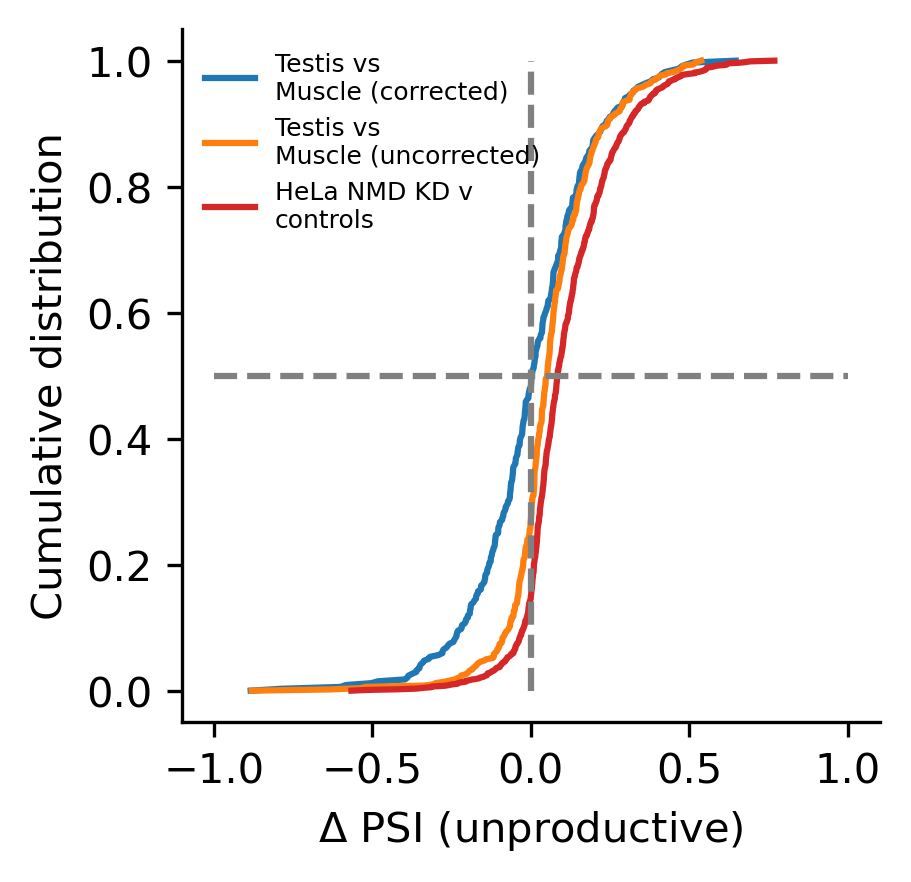

In [220]:
fig, ax = plt.subplots(figsize=(3,3), dpi=300)

y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Testis vs\nMuscle (corrected)'
    )


y = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Testis vs\nMuscle (uncorrected)'
    )

y_dkd = -np.array(ds_dkd.loc[(ds_dkd.itype=='UP') & (ds_dkd.ctype=='PR,UP') & (ds_dkd.median_counts >= 10) & (ds_dkd['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'HeLa NMD KD v\ncontrols', c='tab:red'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')
ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=6)

ax.set_xlabel(r'$\Delta$ PSI (unproductive)')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

plt.savefig('plots/sup_fig6E.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6E.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6E.svg', dpi=300, bbox_inches='tight') 

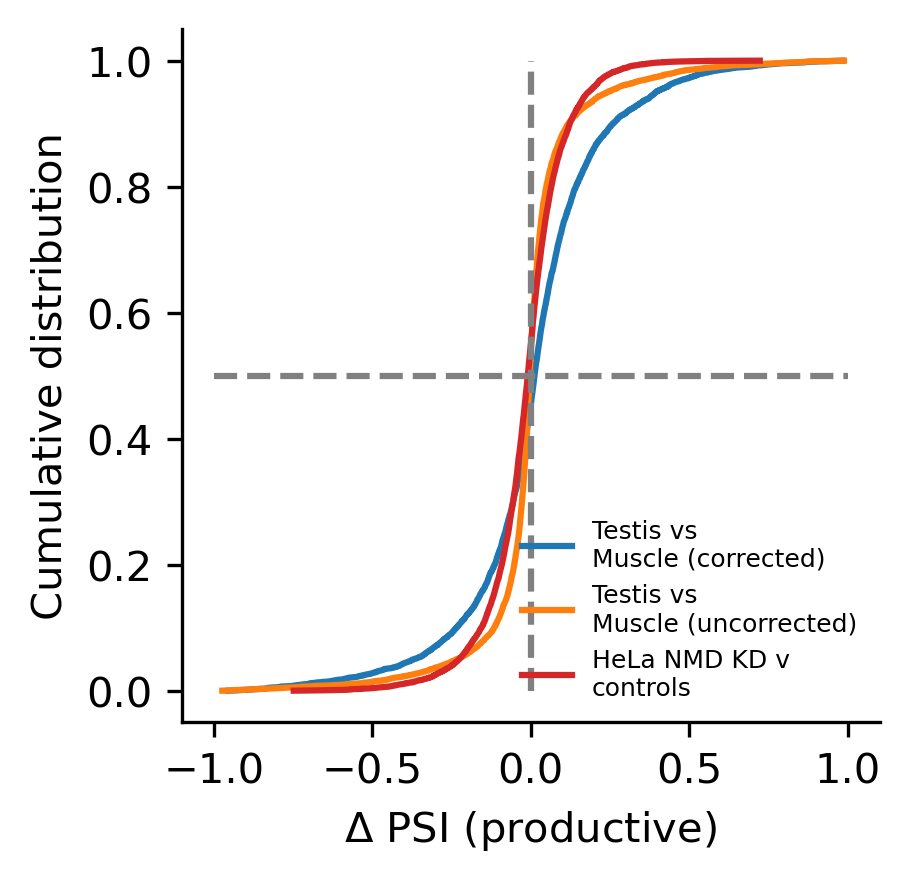

In [221]:
fig, ax = plt.subplots(figsize=(3,3), dpi=300)

y = np.array(ds.loc[(ds.itype=='PR') & (ds.ctype=='PR') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Testis vs\nMuscle (corrected)'
    )


y = np.array(ds_u.loc[(ds_u.itype=='PR') & (ds_u.ctype=='PR') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Testis vs\nMuscle (uncorrected)'
    )

y_dkd = -np.array(ds_dkd.loc[(ds_dkd.itype=='PR') & (ds_dkd.ctype=='PR') & (ds_dkd.median_counts >= 10) & (ds_dkd['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'HeLa NMD KD v\ncontrols', c='tab:red'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')
ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=6)

ax.set_xlabel(r'$\Delta$ PSI (productive)')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

plt.savefig('plots/sup_fig6F.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6F.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6F.svg', dpi=300, bbox_inches='tight') 

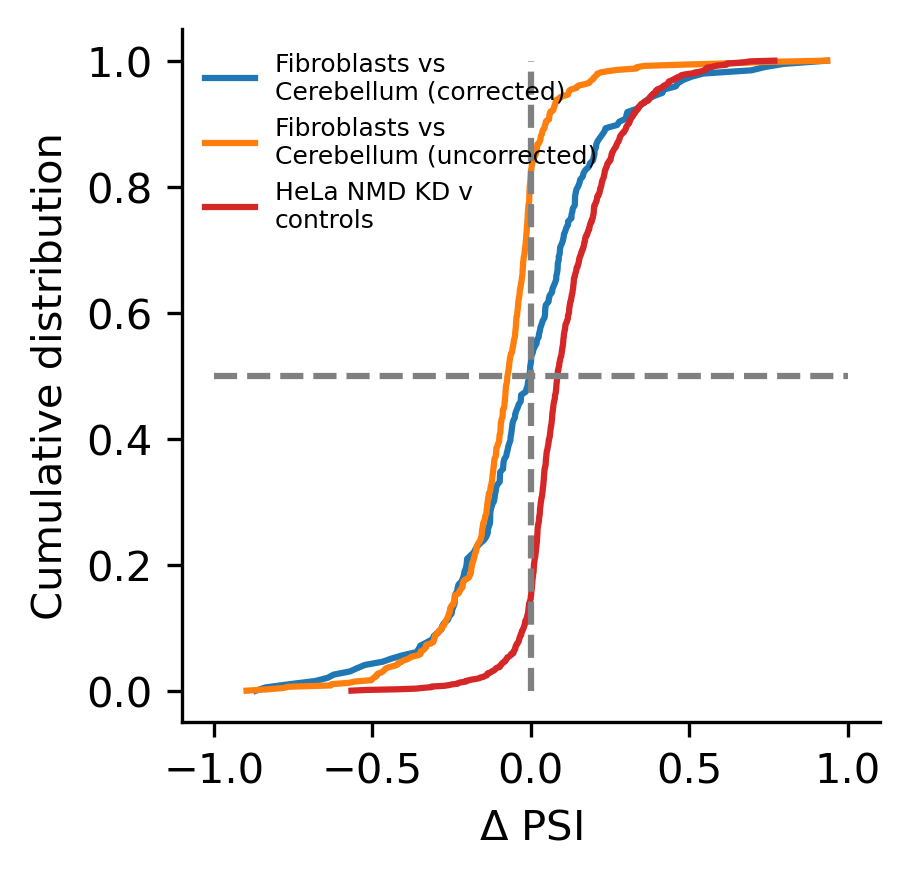

In [215]:
ds_dkd = process_comparison_HeLa('HeLa_dKD_v_controls.rds')
ds = process_comparison('Cells-Culturedfibroblasts_v_Brain-Cerebellum.rds')
ds_u = process_comparison_uncorrected('Cells-Culturedfibroblasts_v_Brain-Cerebellum.rds')


fig, ax = plt.subplots(figsize=(3,3), dpi=300)

y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Fibroblasts vs\nCerebellum (corrected)'
    )


y = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Fibroblasts vs\nCerebellum (uncorrected)'
    )

y_dkd = -np.array(ds_dkd.loc[(ds_dkd.itype=='UP') & (ds_dkd.ctype=='PR,UP') & (ds_dkd.median_counts >= 10) & (ds_dkd['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'HeLa NMD KD v\ncontrols', c='tab:red'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')
ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=6)

ax.set_xlabel(r'$\Delta$ PSI')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

plt.savefig('plots/sup_fig6F.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6F.pdf', dpi=300, bbox_inches='tight')
plt.savefig('plots/sup_fig6F.svg', dpi=300, bbox_inches='tight') 

In [192]:
np.median(y_dkd)

np.float64(0.0837790430927752)

In [19]:
ds_dkd = process_comparison_HeLa('HeLa_UPF1_v_controls.rds')

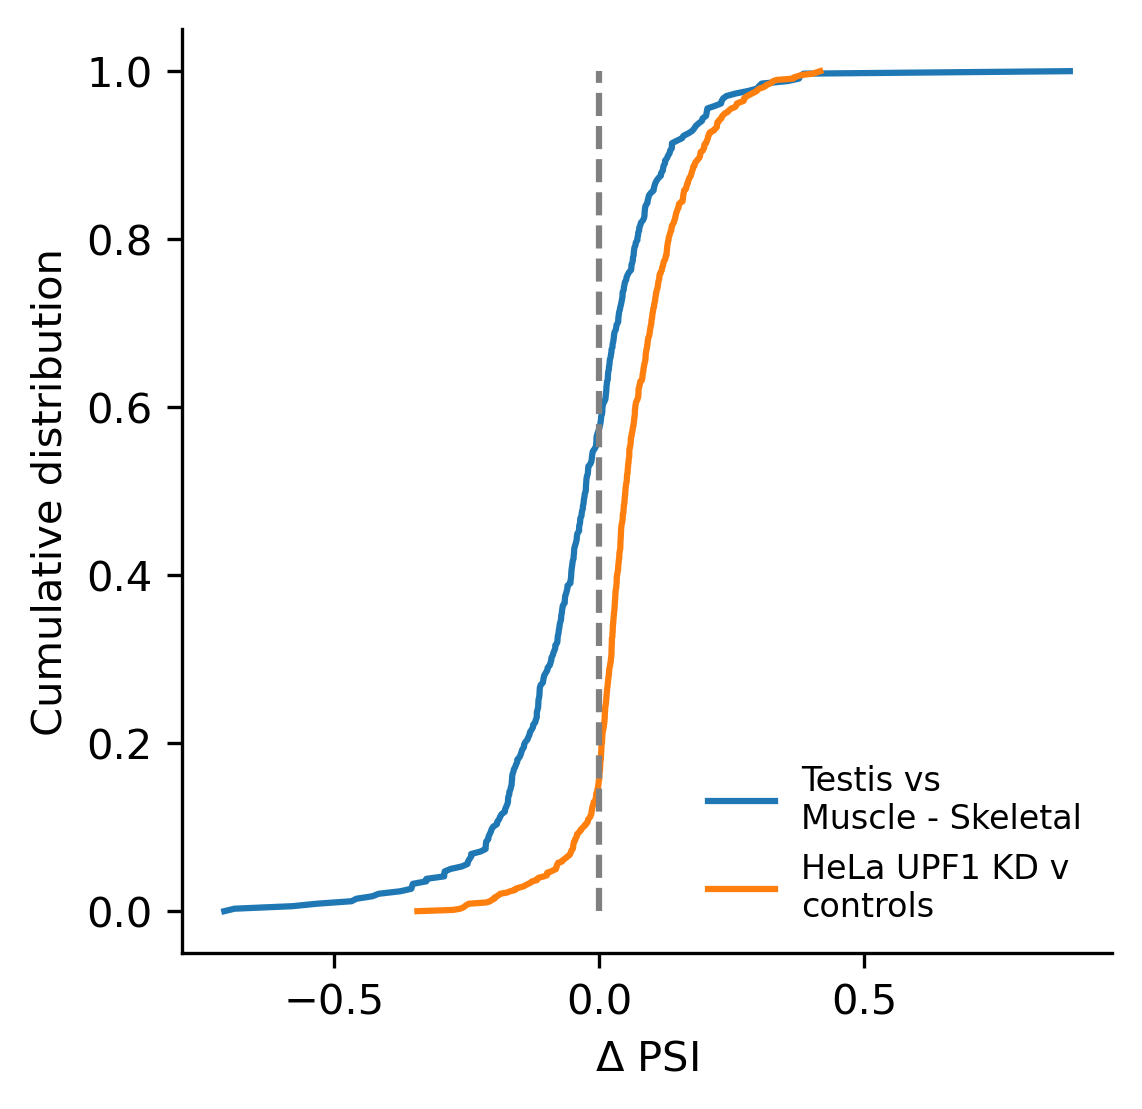

In [20]:

fig, ax = plt.subplots(figsize=(4,4), dpi=300)
y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Testis vs\nMuscle - Skeletal'
    )

y_dkd = -np.array(ds_dkd.loc[(ds_dkd.itype=='UP') & (ds_dkd.ctype=='PR,UP') & (ds_dkd.median_counts >= 10) & (ds_dkd['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'HeLa UPF1 KD v\ncontrols'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

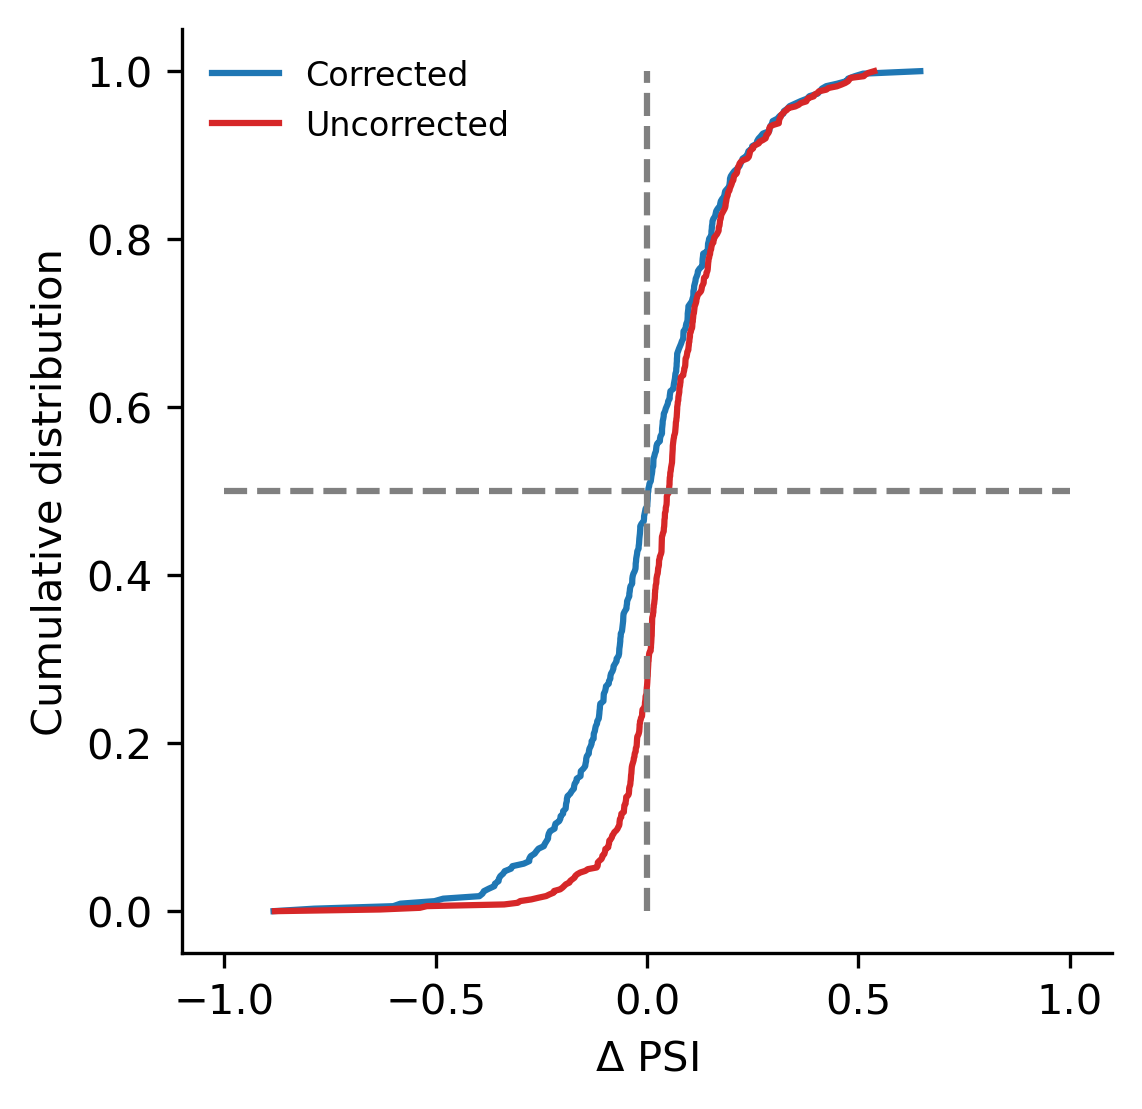

In [68]:
fig, ax = plt.subplots(figsize=(4,4), dpi=300)
y = np.array(ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Corrected'
    )

y_dkd = np.array(ds_u.loc[(ds_u.itype=='UP') & (ds_u.ctype=='PR,UP') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'Uncorrected', c='tab:red'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.plot([-1, 1], [0.5, 0.5], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

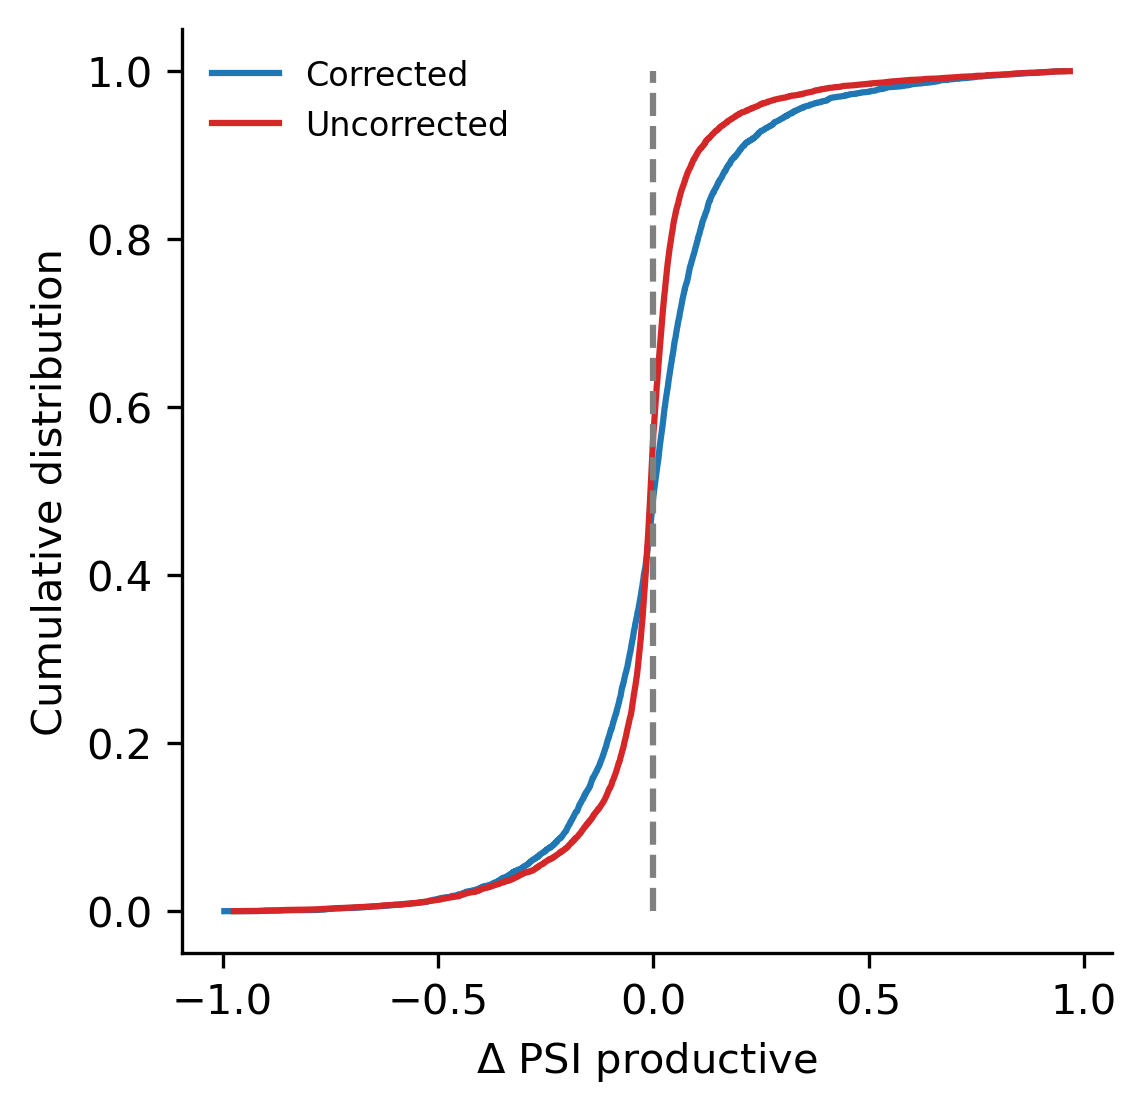

In [22]:
fig, ax = plt.subplots(figsize=(4,4), dpi=300)
y = np.array(ds.loc[(ds.itype=='PR') & (ds.ctype=='PR') & (ds.median_counts >= 10) & (ds['p.adjust']<= 1e-1)].deltapsi)

ax.plot(sorted(y), np.linspace(0, 1, len(y)), label = 'Corrected'
    )

y_dkd = np.array(ds_u.loc[(ds_u.itype=='PR') & (ds_u.ctype=='PR') & (ds_u.median_counts >= 10) & (ds_u['p.adjust']<= 1e-1)].deltapsi)
ax.plot(sorted(y_dkd), np.linspace(0, 1, len(y_dkd)), label = 'Uncorrected', c='tab:red'
    )

ax.plot([0, 0], [0, 1], linestyle='--', c='gray')

ax.legend(frameon=False, fontsize=8)

ax.set_xlabel(r'$\Delta$ PSI productive')
ax.set_ylabel('Cumulative distribution')

ax.spines[['top', 'right']].set_visible(False)

In [188]:

def process_comparison_HeLa_complete(rds_file):
    a_v_b = rds_file.split('.rds')[0]
    readRDS = ro.r['readRDS']
    rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/HeLa_ds_v_dge/{rds_file}')
    
    ds = rds[0]
    with (ro.default_converter + pandas2ri.converter).context():
        pd_from_r_df = ro.conversion.get_conversion().rpy2py(ds)
        output = pd_from_r_df
        
    dge = rds[1]
    with (ro.default_converter + pandas2ri.converter).context():
        pd_from_r_df = ro.conversion.get_conversion().rpy2py(dge)
        dge = pd_from_r_df
        
    intron_list = []
    cluster_list = []
    median_count_list = []
    
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/ds/HeLa/{a_v_b}/ds_perind_numers.counts.noise_by_intron.lf1.gz'
    ) as fh:
        fh.readline()
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-1])
            median_counts = int(np.median([int(y) for y in line[1:]]))
            median_count_list.append(median_counts)
    
    intron_median_counts = pd.DataFrame()
    intron_median_counts['intron'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts['median_counts'] = median_count_list
    
    ds = pd.merge(output, intron_median_counts, right_on=['intron', 'cluster'], left_on=['intron', 'cluster'])
    
    cluster_counts = pd.DataFrame(ds.groupby('cluster').median_counts.sum()).reset_index()
    cluster_counts.columns = ['cluster', 'cluster_counts']

    ds = pd.merge(ds, cluster_counts, right_on='cluster', left_on='cluster')

    dfCluster_max = pd.DataFrame(ds.groupby('gene_id').cluster_counts.max()).reset_index()
    dfCluster_max.columns = ['gene_id', 'max_cluster_counts']

    ds = pd.merge(ds, dfCluster_max, left_on='gene_id', right_on='gene_id')
    ds['cluster_fraction'] = ds.cluster_counts/ds.max_cluster_counts
    
    
    ds_sig_p = ds.loc[(ds.itype=='PR') & (ds.ctype=='PR') & (ds['p.adjust'] <= 1e-1) & (ds.logef.abs() >= 0.1) & (ds.cluster_counts >= 10) ]

    ds_sig_p = pd.merge(ds_sig_p, dge.loc[(dge.padj <= 1e-1) & (dge.log2FoldChange.abs() >= 0.1)], 
                      left_on='gene_id', right_on = 'gene_id').drop_duplicates()

    ds_sig_p = ds_sig_p.groupby('gene_id')[['logef', 'log2FoldChange']].median()
    
    
    ds_sig = ds.loc[(ds.itype=='UP') & (ds.ctype=='PR,UP') & (ds['p.adjust'] <= 1e-1) & (ds.logef.abs() >= 0.1) & (ds.cluster_counts >= 10) ]

    ds_sig = pd.merge(ds_sig, dge.loc[(dge.padj <= 1e-1) & (dge.log2FoldChange.abs() >= 0.1)], 
                      left_on='gene_id', right_on = 'gene_id').drop_duplicates()

    ds_sig = ds_sig.groupby('gene_id')[['logef', 'log2FoldChange']].median()


    return ds_sig, ds_sig_p

In [132]:
rds_file = 'HeLa_UPF1_v_controls.rds'
a_v_b = rds_file.split('.rds')[0]
readRDS = ro.r['readRDS']
rds = readRDS(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/HeLa_ds_v_dge/{rds_file}')

ds = rds[0]
with (ro.default_converter + pandas2ri.converter).context():
    pd_from_r_df = ro.conversion.get_conversion().rpy2py(ds)
    output = pd_from_r_df

dge = rds[1]
with (ro.default_converter + pandas2ri.converter).context():
    pd_from_r_df = ro.conversion.get_conversion().rpy2py(dge)
    dge = pd_from_r_df

In [201]:
pd.DataFrame(ds)

,0,1,2,3,4,5,6,7,8,9,...,76070,76071,76072,76073,76074,76075,76076,76077,76078,76079
0,chr1:924948:925921:clu_10_+,chr1:925189:925921:clu_10_+,chr1:925800:925921:clu_10_+,chr1:930336:931038:clu_11_+,chr1:930336:935771:clu_11_+,chr1:931089:935771:clu_11_+,chr1:939129:939271:clu_12_+,chr1:939129:939274:clu_12_+,chr1:939412:941143:clu_13_+,chr1:939412:942409:clu_13_+,...,chrX:155065789:155070693:clu_47878_-,chrX:155066057:155070693:clu_47878_-,chrX:155280068:155298784:clu_47880_-,chrX:155298910:155299035:clu_47880_-,chrX:155492495:155506897:clu_47884_-,chrX:155492700:155506897:clu_47884_-,chrX:155545277:155612791:clu_47885_-,chrX:155612604:155612791:clu_47885_-,chrY:5000605:5030898:clu_47890_+,chrY:5031067:5031905:clu_47890_+
1,chr1:clu_10_+,chr1:clu_10_+,chr1:clu_10_+,chr1:clu_11_+,chr1:clu_11_+,chr1:clu_11_+,chr1:clu_12_+,chr1:clu_12_+,chr1:clu_13_+,chr1:clu_13_+,...,chrX:clu_47878_-,chrX:clu_47878_-,chrX:clu_47880_-,chrX:clu_47880_-,chrX:clu_47884_-,chrX:clu_47884_-,chrX:clu_47885_-,chrX:clu_47885_-,chrY:clu_47890_+,chrY:clu_47890_+
2,PR,PR,PR,PR,PR,PR,PR,PR,PR,PR,...,NE,PR,PR,PR,PR,PR,PR,NE,PR,PR
3,PR,PR,PR,PR,PR,PR,PR,PR,"PR,UP","PR,UP",...,"NE,PR","NE,PR",PR,PR,PR,PR,"NE,PR","NE,PR",PR,PR
4,SAMD11,SAMD11,SAMD11,SAMD11,SAMD11,SAMD11,SAMD11,SAMD11,SAMD11,SAMD11,...,MTCP1,MTCP1,CLIC2,CLIC2,TMLHE,TMLHE,TMLHE,TMLHE,PCDH11Y,PCDH11Y
5,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,ENSG00000187634.11,...,ENSG00000214827.9,ENSG00000214827.9,ENSG00000155962.12,ENSG00000155962.12,ENSG00000185973.10,ENSG00000185973.10,ENSG00000185973.10,ENSG00000185973.10,ENSG00000099715.14,ENSG00000099715.14
6,-0.028213,-0.375139,0.403352,0.050767,-0.034291,-0.016476,-0.100289,0.100289,0.965047,-0.865439,...,0.833051,-1.023422,0.478801,-0.478801,-0.798116,0.798116,-0.138861,0.138861,-0.084679,0.084679
7,0.689024,0.264852,0.046123,0.453249,0.026666,0.520085,0.437656,0.562344,0.048043,0.031621,...,0.05418,0.079204,0.352182,0.647818,0.974603,0.025397,0.986305,0.013695,0.851999,0.148001
8,0.727393,0.197638,0.074969,0.470173,0.025406,0.50442,0.389062,0.610938,0.133195,0.014056,...,0.075726,0.017294,0.586166,0.413834,0.886064,0.113936,0.982,0.018,0.829347,0.170653
9,0.038369,-0.067214,0.028846,0.016925,-0.00126,-0.015665,-0.048594,0.048594,0.085153,-0.017565,...,0.021546,-0.06191,0.233984,-0.233984,-0.088538,0.088538,-0.004305,0.004305,-0.022652,0.022652


In [189]:
ds_sig, ds_sig_p = process_comparison_HeLa_complete(rds_file)

In [190]:
ds_sig = -ds_sig
ds_sig_p = -ds_sig_p

In [191]:
(ds_sig.logef <= 0).mean()

np.float64(0.19047619047619047)

In [203]:
Y = ds_sig_p['logef']
X = ds_sig_p['log2FoldChange']
spearmanr(X, Y)

SignificanceResult(statistic=np.float64(0.006366865211294846), pvalue=np.float64(0.9052521447326258))

In [198]:
ds_sig_p.logef.abs() >= 0.1

gene_id
ENSG00000001497.16    False
ENSG00000002330.13     True
ENSG00000002919.14    False
ENSG00000003096.14    False
ENSG00000008282.8      True
                      ...  
ENSG00000266338.6      True
ENSG00000267060.5      True
ENSG00000269313.5      True
ENSG00000269713.7     False
ENSG00000278259.4      True
Name: logef, Length: 352, dtype: bool

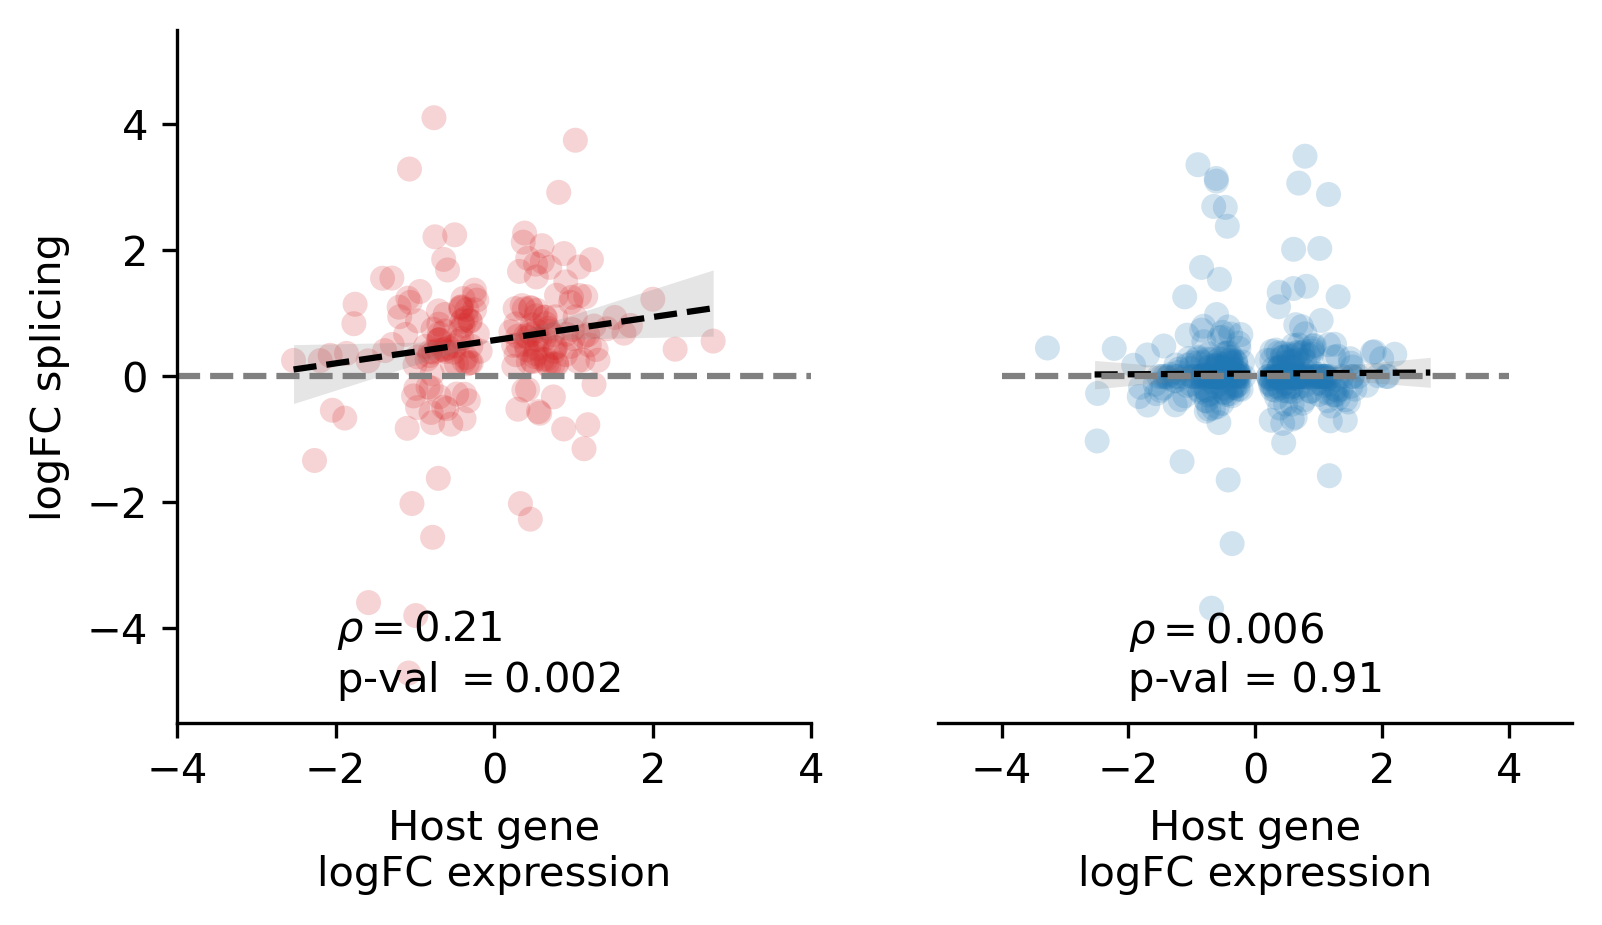

In [205]:
# ===== MAIN FIGURE CELL -- COMMENTED OUT =====
# Builds fig2B, which is a main figure reproduced
# properly in ../Figure2/ or ../Figure4/. Nothing later in this notebook
# uses what it defines, so it is disabled here.
# rho_list = []
# for i in range(100):
#     idx = np.random.choice(np.arange(ds_sig.shape[0]), 30, replace=False)
#
#     Y = np.array(list(ds_sig.logef))[idx]
#     X = np.array(list(ds_sig.log2FoldChange))[idx]
#     X = sm.add_constant(X)
#
#
#     model = sm.RLM(Y,X)
#     results = model.fit()
#
#     slope = results.params[1]
#     const = results.params[0]
#
#     rho_list.append(slope)
#
# fig, ax = plt.subplots(ncols = 2, figsize=(6, 3), dpi=300)
#
# ax[0].scatter(ds_sig.log2FoldChange, ds_sig.logef, facecolor='tab:red', edgecolor='none', alpha=0.2, rasterized=True)
#
#
#
# Y = ds_sig['logef']
# X = ds_sig['log2FoldChange']
# X = sm.add_constant(X)
#
# model = sm.RLM(Y,X)
# results = model.fit()
#
# slope = results.params.loc['log2FoldChange']
# const = results.params.loc['const']
#
#
# # slope = pearsonr(list(ds_sig.logef), list(ds_sig.log2FoldChange))[0]
# # intercept = np.mean(list(ds_sig.log2FoldChange))
# slope_90 = np.quantile(rho_list, 0.9)
# slope_10 = np.quantile(rho_list, 0.1)
#
# # Plot confidence intervals (optional)
#
# # x = np.linspace(-7.5, 8.5, 100)
#
#
#
# mean_X = np.mean(X.log2FoldChange)
#
# x = np.linspace(np.min(ds_sig.log2FoldChange)-mean_X, np.max(ds_sig.log2FoldChange)-mean_X, 100)
#
# ax[0].plot(x + mean_X, (slope * (x+mean_X)) + const, color='black', linestyle='--')
#
#
# ax[0].fill_between(x + mean_X,( slope_90 * np.array(x)) + const + (slope*mean_X),
#                 (slope_10 * x) + const+ (slope*mean_X),
#                  color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)
#
#
#
#
#
#
# # ax[0].plot(x, slope * x + 0, color='black', linestyle='--')
#
#
# # ax[0].fill_between(x,( slope_90 * np.array(x)) + 0,
# #                 (slope_10 * x) + 0,
# #                  color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)
#
# ax[0].set_ylim([-5.5, 5.5])
# ax[0].set_xlim([-4, 4])
# ax[0].spines[['top', 'right']].set_visible(False)
#
# # ax.set_xlim([-3.5, 3.5])
#
# # ax.set_ylim([-1.8, 1.8])
# ax[0].text(-2, -5, r'$\rho = 0.21$' + '\np-val $= 0.002$')
#
# ax[0].set_ylabel('logFC splicing')
# ax[0].set_xlabel('Host gene\nlogFC expression')
#
#
#
#
# ####################
#
# rho_list = []
# for i in range(100):
#     idx = np.random.choice(np.arange(ds_sig_p.shape[0]), 30, replace=False)
#
#     Y = np.array(list(ds_sig_p.logef))[idx]
#     X = np.array(list(ds_sig_p.log2FoldChange))[idx]
#     X = sm.add_constant(X)
#
#
#     model = sm.RLM(Y,X)
#     results = model.fit()
#
#     slope = results.params[1]
#     const = results.params[0]
#
#     rho_list.append(slope)
#
#
# ax[1].scatter(ds_sig_p.log2FoldChange, ds_sig_p.logef, facecolor='tab:blue', edgecolor='none', alpha=0.2, rasterized=True)
#
#
#
# Y = ds_sig_p['logef']
# X = ds_sig_p['log2FoldChange']
# X = sm.add_constant(X)
#
# model = sm.RLM(Y,X)
# results = model.fit()
#
# slope = results.params.loc['log2FoldChange']
# const = results.params.loc['const']
#
#
# # slope = pearsonr(list(ds_sig.logef), list(ds_sig.log2FoldChange))[0]
# # intercept = np.mean(list(ds_sig.log2FoldChange))
# slope_90 = np.quantile(rho_list, 0.9)
# slope_10 = np.quantile(rho_list, 0.1)
#
# # Plot confidence intervals (optional)
#
#
#
# mean_X = np.mean(X.log2FoldChange)
#
# x = np.linspace(np.min(ds_sig.log2FoldChange)-mean_X, np.max(ds_sig.log2FoldChange)-mean_X, 100)
#
# ax[1].plot(x + mean_X, (slope * (x+mean_X)) + const, color='black', linestyle='--')
#
#
# ax[1].fill_between(x + mean_X,( slope_90 * np.array(x)) + const + (slope*mean_X),
#                 (slope_10 * x) + const+ (slope*mean_X),
#                  color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)
#
#
#
#
#
# # x = np.linspace(-7.5, 8.5, 100)
#
# # ax[1].plot(x, slope * x + 0, color='black', linestyle='--')
#
#
# # ax[1].fill_between(x,( slope_90 * np.array(x)) + 0,
# #                 (slope_10 * x) + 0,
# #                  color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)
#
# ax[1].set_ylim([-5.5, 5.5])
# ax[1].set_xlim([-5, 5])
# ax[1].spines[['top', 'right', 'left']].set_visible(False)
#
# # ax.set_xlim([-3.5, 3.5])
#
# # ax.set_ylim([-1.8, 1.8])
# ax[1].text(-2, -5, r'$\rho = 0.006$' + '\np-val = 0.91')
#
# # ax[1].set_ylabel('logFC splicing')
# ax[1].set_yticks([])
# ax[1].set_xlabel('Host gene\nlogFC expression')
#
#
# ax[0].plot([-4, 4], [0, 0], c='gray', linestyle='--')
# ax[1].plot([-4, 4], [0, 0], c='gray', linestyle='--')
#
# # plt.savefig('plots/fig2B.png', dpi=300, bbox_inches='tight')
# # plt.savefig('plots/fig2B.pdf', dpi=300, bbox_inches='tight')
# # plt.savefig('plots/fig2B.svg', dpi=300, bbox_inches='tight')

In [187]:
ds_sig.logef.abs().min()

np.float64(0.04241124218506298)